# Olist 프로젝트 - 배송 경험과 리뷰 점수의 관계

## 데이터셋
- Olist Brazilian E-Commerce (Kaggle)

## 문제정의
- 배송 관련 요인이 고객 만족도(리뷰 점수)에 얼마나, 어떻게 영향을 미치는가?
- 개선이 시급한 지역은 어디이며, 왜 그런가?

## 목적
- 배송 소요일/정시성/지연 정도가 리뷰 점수와 실제로 관계가 있는지 통계적으로 검증하고 (H1~H3)
- 그 관계를 바탕으로 지역별로 원인을 진단해서 (H4~H5), 어디를 왜 개선해야 하는지 도출하고
- 진단 결과를 바탕으로 실행 가능한 액션(물류거점 입지 제안)까지 제시

## 가설목록
- H1. 배송 소요일이 짧을수록 리뷰점수가 높을 것이다
- H2. 배송 소요일 자체보다 정시성(예상 대비 지연 여부)이 리뷰점수에 더 큰 영향을 미칠 것이다
- H3. 지연된 주문 중에서는, 지연 폭이 클수록 리뷰점수가 더 낮아질 것이다
- H4. 배송 지연이 만족도에 미치는 영향의 크기는 지역별로 차이가 있을 것이다
- H5. 판매자-구매자 간 거리가 멀수록 배송이 느리고 리뷰점수가 낮을 것이다

In [1]:
# 목적: 구글드라이브 마운트 + duckdb 설치 + Olist 데이터 접근 확인
from google.colab import drive
drive.mount('/content/drive')

!pip install duckdb -q

import duckdb
con = duckdb.connect()

# 데이터 폴더 경로 (Olist CSV 파일들이 있는 위치, 팀 노트북 구조에 맞춰 확인)
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/olist'

# 경로 확인
import os
print(os.listdir(DATA_PATH))

Mounted at /content/drive
['olist_customers_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'product_category_name_translation.csv', 'olist_products_dataset.csv', 'olist_order_items_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_sellers_dataset.csv', 'customer-personality-analysis.ipynb', 'marketing_campaign.csv']


In [2]:
# 목적: 시각화용 한글 폰트 설치 및 적용 (나눔고딕)
!apt-get -qq -y install fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False  # 한글 폰트 쓸 때 마이너스 기호 깨짐 방지

print("폰트 적용 완료:", fm.FontProperties(fname=font_path).get_name())

폰트 적용 완료: NanumBarunGothic


In [75]:
# 목적: 공통 준비 - 배송 파생컬럼 4종 + 대표 판매자 판별 + H4~H5용 컬럼 포함한 base 테이블 생성
import duckdb

con = duckdb.connect()

orders_path = f'{DATA_PATH}/olist_orders_dataset.csv'
order_items_path = f'{DATA_PATH}/olist_order_items_dataset.csv'
order_reviews_path = f'{DATA_PATH}/olist_order_reviews_dataset.csv'
customers_path = f'{DATA_PATH}/olist_customers_dataset.csv'
sellers_path = f'{DATA_PATH}/olist_sellers_dataset.csv'

query = f"""
WITH order_items_dedup AS (
    -- 주문 하나당 셀러가 여러 명 겹치는 경우, 대표 셀러 1명만 사용 (order_item_id 기준 첫번째)
    SELECT order_id, seller_id, shipping_limit_date,
        ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY order_item_id) AS rn
    FROM read_csv_auto('{order_items_path}')
),
reviews_dedup AS (
    -- 리뷰도 한 주문에 여러 건이면 가장 최신 리뷰만 사용
    SELECT order_id, review_score,
        ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY review_creation_date DESC) AS rn
    FROM read_csv_auto('{order_reviews_path}')
)
SELECT
    o.order_id,
    o.customer_id,
    c.customer_state,
    c.customer_zip_code_prefix,
    oi.seller_id,
    s.seller_state,
    s.seller_zip_code_prefix,
    oi.shipping_limit_date,
    o.order_purchase_timestamp,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    DATE_DIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date) AS 배송소요일,
    DATE_DIFF('day', o.order_estimated_delivery_date, o.order_delivered_customer_date) AS 지연일수,
    DATE_DIFF('day', o.order_purchase_timestamp, o.order_delivered_carrier_date) AS 판매자처리일수,
    DATE_DIFF('day', o.order_delivered_carrier_date, o.order_delivered_customer_date) AS 배송사운송일수,
    r.review_score
FROM read_csv_auto('{orders_path}') o
LEFT JOIN order_items_dedup oi ON o.order_id = oi.order_id AND oi.rn = 1
LEFT JOIN read_csv_auto('{sellers_path}') s ON oi.seller_id = s.seller_id
LEFT JOIN read_csv_auto('{customers_path}') c ON o.customer_id = c.customer_id
LEFT JOIN reviews_dedup r ON o.order_id = r.order_id AND r.rn = 1
WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_delivered_carrier_date IS NOT NULL
"""

base_df = con.execute(query).df()
print(base_df.shape)
base_df.head()

(96469, 17)


,order_id,customer_id,customer_state,customer_zip_code_prefix,seller_id,seller_state,seller_zip_code_prefix,shipping_limit_date,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,배송소요일,지연일수,판매자처리일수,배송사운송일수,review_score
0,0b339dee90210409b715a9f2b6af29a7,fb7df68b487c7340f5a4e9c5d4ae3e73,SP,04551,b32be1695eb7ec5f10f72d9610a12527,RS,95012,2017-12-07 13:58:25,2017-11-29 13:49:23,2017-12-06 00:41:50,2017-12-11 20:12:32,2017-12-28,12,-17,7,5,4
1,2149fe82b3e2d55f500ffe8406412733,b1f561df601049692eeba1996a9d4eea,SP,05818,3d871de0142ce09b7081e2b9d1733cb1,SP,13232,2018-05-04 00:30:34,2018-04-28 00:21:17,2018-04-30 07:37:00,2018-05-04 18:42:31,2018-05-21,6,-17,2,4,2
2,b9224c19c5ea3ae062a0141931846476,06363955dfbb8c28438d249c8670e6b9,MG,38748,85d9eb9ddc5d00ca9336a2219c97bb13,MG,31255,2017-06-27 02:26:07,2017-06-20 14:21:18,2017-06-26 17:07:52,2017-06-27 19:52:10,2017-07-10,7,-13,6,1,5
3,f6586a410980be02b8a408eb2d0a5c21,ca5c87a30556fbad0671e0b2f9a57915,PE,56140,96493fab2fbb13a14d0c0e8772eef5c3,SP,05537,2017-05-26 02:15:42,2017-05-16 22:42:57,2017-05-18 14:49:26,2017-06-07 08:48:00,2017-06-22,22,-15,2,20,3
4,3ce8c5cf3d6b4356d90656b6ac73ab9a,4c73c9714637b75675607a0714c0c139,SP,13563,891071be6ba827b591264c90c2ae8a63,SP,03872,2017-07-16 21:55:18,2017-07-10 21:37:19,2017-07-21 22:43:32,2017-07-25 19:36:41,2017-08-09,15,-15,11,4,5


In [4]:
# 목적: base_df의 핵심 수치형 컬럼(배송소요일, 지연일수, 판매자처리일수, 배송사운송일수, review_score) 결측치와 기초통계 확인
cols = ['배송소요일', '지연일수', '판매자처리일수', '배송사운송일수', 'review_score']

print("결측치 개수:")
print(base_df[cols].isnull().sum())

print("\n기초 통계:")
base_df[cols].describe()

결측치 개수:
배송소요일             0
지연일수              0
판매자처리일수           0
배송사운송일수           0
review_score    646
dtype: int64

기초 통계:


,배송소요일,지연일수,판매자처리일수,배송사운송일수,review_score
count,96469.000000,96469.000000,96469.000000,96469.000000,95823.0
mean,12.496439,-11.876074,3.213913,9.282526,4.155808
std,9.554274,10.181995,3.611457,8.777037,1.284789
min,0.000000,-147.000000,-171.000000,-16.000000,1.0
25%,7.000000,-17.000000,1.000000,4.000000,4.0
50%,10.000000,-12.000000,2.000000,7.000000,5.0
75%,16.000000,-7.000000,4.000000,12.000000,5.0
max,210.000000,188.000000,126.000000,205.000000,5.0


In [5]:
# 목적: base_df 실제 컬럼명 확인 (KeyError 원인 파악용)
print(base_df.columns.tolist())

['order_id', 'customer_id', 'customer_state', 'customer_zip_code_prefix', 'seller_id', 'seller_state', 'seller_zip_code_prefix', 'shipping_limit_date', '판매자총거래량', 'order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', '배송소요일', '지연일수', '판매자처리일수', '배송사운송일수', 'review_score']


## 데이터 품질 확인 — 결측치 및 이상치 점검

**목적**
base_df를 만든 직후, H1~H5 전체 분석에 쓰일 핵심 컬럼(배송소요일, 지연일수, 판매자처리일수, 배송사운송일수, review_score)에 결측치나 논리적으로 불가능한 값이 있는지 확인

**관찰**
- 배송소요일, 지연일수는 결측 0건
- 판매자처리일수, 배송사운송일수는 결측 1건씩인데, 더 큰 문제는 최솟값이 음수(-171일, -16일)라는 점 — 배송사 도착일이 발송일보다 빠른 건 실제로는 불가능한 데이터 오류값
- review_score는 646건 결측 — 리뷰를 남기지 않은 주문으로, 정상적인 상황(주문은 완료됐지만 리뷰 미작성)

**결론**
- 판매자처리일수/배송사운송일수의 음수값은 논리적으로 발생할 수 없으므로 제거하기로 결정
- review_score 결측은 정상 케이스라 별도로 제거하지 않고, review_score가 필요한 분석에서만 그때그때 제외하기로 함

**다음 단계**
- 판매자처리일수 ≥ 0, 배송사운송일수 ≥ 0 조건으로 base_df 필터링
- 이후 H1(배송소요일-리뷰점수 관계)부터 다시 순서대로 검증

In [6]:
# 목적: 데이터 품질 문제 제거 - 논리적으로 불가능한 값(음수 처리일수/운송일수) 필터링
before = len(base_df)
base_df = base_df[(base_df['판매자처리일수'] >= 0) & (base_df['배송사운송일수'] >= 0)].copy()
print(f"음수 처리일수/운송일수 제외: {before} -> {len(base_df)}")
print("\nreview_score 결측(리뷰 없는 주문):", base_df['review_score'].isnull().sum())

음수 처리일수/운송일수 제외: 96469 -> 96447

review_score 결측(리뷰 없는 주문): 646


## 이상치 확인 — 배송소요일 극단값 검증

**배경 (왜 확인하는지)**
음수값 필터링과 별개로, 배송소요일 자체에도 극단적으로 큰 값들이 있는지 확인 필요. 통계에서 흔히 쓰는 사분위수(IQR) 기준으로 먼저 이상치 범위를 잡아보고 판단

In [7]:
# 목적: 배송소요일 이상치 범위 확인 (IQR 기준) - 제거 여부 판단을 위한 근거 확보
q1 = base_df['배송소요일'].quantile(0.25)
q3 = base_df['배송소요일'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1: {q1:.1f}일, Q3: {q3:.1f}일, IQR: {iqr:.1f}일")
print(f"IQR 기준 정상범위: {lower:.1f}일 ~ {upper:.1f}일")

n_outlier = ((base_df['배송소요일'] < lower) | (base_df['배송소요일'] > upper)).sum()
print(f"\nIQR 기준 이상치 건수: {n_outlier}건 ({n_outlier/len(base_df)*100:.2f}%)")

print("\n상위 극단값 10건:")
print(base_df.nlargest(10, '배송소요일')[['order_id', '배송소요일', 'review_score']])

Q1: 7.0일, Q3: 16.0일, IQR: 9.0일
IQR 기준 정상범위: -6.5일 ~ 29.5일

IQR 기준 이상치 건수: 4728건 (4.90%)

상위 극단값 10건:
                               order_id  배송소요일  review_score
96080  ca07593549f1816d26a572e06dc1eab6    210          <NA>
79179  1b3190b2dfa9d789e1f14c05b647a14a    208             2
5417   440d0d17af552815d15a9e41abe49359    196             1
32054  285ab9426d6982034523a855f55a885e    195             1
79787  2fb597c2f772eca01b1f5c561bf6cc7b    195             4
65661  0f4519c5f1c541ddec9f21b3bddd533a    194             4
77391  47b40429ed8cce3aee9199792275433f    191             1
61983  2fe324febf907e3ea3f2aa9650869fa5    190             1
10782  c27815f7e3dd0b926b58552628481575    188             3
76922  2d7561026d542c8dbd8f0daeadf67a43    188             3


**관찰 (사분위수 기준 결과)**
- IQR 기준 정상범위는 -6.5일~29.5일이고, 이 기준으로는 이상치가 4.9%(4,728건)나 잡힘
- 배송소요일처럼 0 이상이고 오른쪽으로 긴 분포에는 IQR 규칙이 안 맞을 수 있음 (정상적인 긴 꼬리도 다 이상치로 잡아버림)
- 상위 극단값 10건의 review_score를 보면 1~4점대로 낮은 쪽에 몰려있음 → 데이터 오류보다는 실제 지연 상황일 가능성

**결론**
사분위수만으로 제거 여부를 판단하기엔 근거가 부족함. 극단값 케이스들의 실제 날짜 흐름을 직접 확인해서 판단하기로 함

**다음 단계**
배송소요일 상위 극단값들의 구매일~예상도착일 전체 타임라인을 직접 확인

In [8]:
# 목적: 배송소요일 상위 극단값 케이스들의 실제 타임라인 직접 확인
extreme_cases = base_df.nlargest(15, '배송소요일')[[
    'order_id',
    'order_purchase_timestamp',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    '배송소요일', '지연일수', '판매자처리일수', '배송사운송일수', 'review_score'
]]
extreme_cases

,order_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,배송소요일,지연일수,판매자처리일수,배송사운송일수,review_score
96080,ca07593549f1816d26a572e06dc1eab6,2017-02-21 23:31:27,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,210,181,15,195,<NA>
79179,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-23 14:57:35,2018-02-26 18:49:07,2018-09-19 23:24:07,2018-03-15,208,188,3,205,2
5417,440d0d17af552815d15a9e41abe49359,2017-03-07 23:59:51,2017-03-15 13:00:08,2017-09-19 15:12:50,2017-04-07,196,165,8,188,1
32054,285ab9426d6982034523a855f55a885e,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,2017-04-06,195,166,1,194,1
79787,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-08 18:09:02,2017-03-13 08:54:02,2017-09-19 14:33:17,2017-04-17,195,155,5,190,4
65661,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,194,161,13,181,4
77391,47b40429ed8cce3aee9199792275433f,2018-01-03 09:44:01,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,191,175,34,157,1
61983,2fe324febf907e3ea3f2aa9650869fa5,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,2017-04-05,190,167,4,186,1
10782,c27815f7e3dd0b926b58552628481575,2017-03-15 23:23:17,2017-03-21 14:50:25,2017-09-19 17:14:25,2017-04-10,188,162,6,182,3
76922,2d7561026d542c8dbd8f0daeadf67a43,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,188,159,1,187,3


## 이상치 확인 — 극단값의 09-19 날짜 집중 현상

**관찰**
- 배송소요일 상위 15건 극단값 중 11건이 order_delivered_customer_date가 정확히 2017-09-19 또는 2018-09-19로 찍혀있음
- 이 11건의 판매자처리일수는 1-34일로 정상 범위인데, 배송사운송일수만 150-205일로 비정상적으로 큼
- 즉 판매자 쪽이 아니라 배송사 인계 이후 구간에서만 문제 발생 → 개별 주문의 실제 배송 지연이 아니라, 특정 날짜에 밀려있던 주문들을 시스템이 일괄로 '배송완료' 처리한 흔적일 가능성

**가설**
09-19(2017년, 2018년 각각 연 1회)에 오래 밀려있던 주문들을 시스템이 일괄로 배송완료 처리했을 것이다

**다음 확인할 것**
09-19에 도착 처리된 주문 전체(이전에 확인한 2017-09-19 282건 + 2018-09-19 3건)의 배송사운송일수 분포가 다른 날짜들과 다르게 비정상적으로 넓게 퍼져있는지 비교해서 가설 검증

In [9]:
# 목적: 09-19 도착 건이 실제로 '일괄 처리 흔적'인지 확인 - 해당 날짜의 배송사운송일수 분포가 다른 날짜와 다른지 비교
base_df['도착일'] = base_df['order_delivered_customer_date'].dt.date.astype(str)
target_dates = ['2017-09-19', '2018-09-19']

sep19 = base_df[base_df['도착일'].isin(target_dates)]
others = base_df[~base_df['도착일'].isin(target_dates)]

print(f"09-19 도착 건수: {len(sep19)}건")
print("\n[09-19 도착 건의 배송사운송일수 분포]")
print(sep19['배송사운송일수'].describe())

print("\n[다른 날짜 도착 건의 배송사운송일수 분포]")
print(others['배송사운송일수'].describe())

09-19 도착 건수: 285건

[09-19 도착 건의 배송사운송일수 분포]
count    285.000000
mean      24.947368
std       44.865849
min        1.000000
25%        6.000000
50%        7.000000
75%       18.000000
max      205.000000
Name: 배송사운송일수, dtype: float64

[다른 날짜 도착 건의 배송사운송일수 분포]
count    96162.000000
mean         9.237017
std          8.382900
min          0.000000
25%          4.000000
50%          7.000000
75%         12.000000
max        181.000000
Name: 배송사운송일수, dtype: float64


## 이상치 확인 — 09-19 배송사운송일수 분포 검증 결과

**관찰**
- 09-19 도착 285건의 배송사운송일수 중앙값은 7.0일로, 다른 날짜(중앙값 7.0일)와 완전히 동일 - 대부분은 정상 배송
- 하지만 75%지점이 18일(다른 날짜 12일), 최댓값이 205일(다른 날짜 181일)로 상위 구간만 확실히 튐
- 앞서 확인한 극단값 상위 15건 중 11건이 09-19에 몰려있었던 것과 종합하면, 09-19 전체(285건) 중 일부(약 3.9%)만 극단값이고 나머지는 정상
- 진짜 물류 지연이면 오래 걸린 주문들이 여러 날짜에 흩어져야 정상인데, 2017년과 2018년 두 해 모두 똑같이 09-19에 몰리는 건 우연으로 보기 어려움 - 일괄 처리 흔적 가능성

**결론**
09-19 전체를 제외하는 건 과함(대부분 정상). 09-19 도착 건 중에서도 배송사운송일수가 비정상적으로 큰 일부만 데이터 오류로 보고 제외하기로 함

**다음 단계**
09-19 도착 + 배송사운송일수 비정상 구간(예: 50일 이상)에 해당하는 건이 몇 건인지 확인해서 제외 기준 확정

In [10]:
# 목적: 09-19 도착 건 중 배송사운송일수가 비정상적으로 큰 건이 몇 건인지 확인 (제외 기준 확정용)
threshold = 50  # 일반 분포 최댓값(181일)보다 훨씬 관대하게 잡은 기준

suspect = sep19[sep19['배송사운송일수'] >= threshold]
print(f"09-19 도착 + 배송사운송일수 {threshold}일 이상: {len(suspect)}건 / 전체 09-19 {len(sep19)}건")
suspect[['order_id', 'order_delivered_carrier_date', 'order_delivered_customer_date',
         '배송사운송일수', 'review_score']].sort_values('배송사운송일수', ascending=False)

09-19 도착 + 배송사운송일수 50일 이상: 32건 / 전체 09-19 285건


,order_id,order_delivered_carrier_date,order_delivered_customer_date,배송사운송일수,review_score
79179,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-26 18:49:07,2018-09-19 23:24:07,205,2
96080,ca07593549f1816d26a572e06dc1eab6,2017-03-08 13:47:46,2017-09-19 14:36:39,195,<NA>
32054,285ab9426d6982034523a855f55a885e,2017-03-09 08:53:20,2017-09-19 14:00:04,194,1
79787,2fb597c2f772eca01b1f5c561bf6cc7b,2017-03-13 08:54:02,2017-09-19 14:33:17,190,4
5417,440d0d17af552815d15a9e41abe49359,2017-03-15 13:00:08,2017-09-19 15:12:50,188,1
76922,2d7561026d542c8dbd8f0daeadf67a43,2017-03-16 09:29:16,2017-09-19 14:38:18,187,3
61983,2fe324febf907e3ea3f2aa9650869fa5,2017-03-17 07:23:53,2017-09-19 17:00:07,186,1
10782,c27815f7e3dd0b926b58552628481575,2017-03-21 14:50:25,2017-09-19 17:14:25,182,3
57884,437222e3fd1b07396f1d9ba8c15fba59,2017-03-21 08:22:43,2017-09-19 16:28:58,182,5
43158,dfe5f68118c2576143240b8d78e5940a,2017-03-21 18:28:04,2017-09-19 18:13:19,182,4


## 이상치 확인 — 09-19 극단값 32건 최종 판단

**관찰**
- 배송사운송일수 50일 이상 + 09-19 도착 건은 32건
- 이 32건의 order_delivered_carrier_date는 2017년 3월~7월(2018년은 2월/7월)에 걸쳐 넓게 흩어져 있는데, order_delivered_customer_date는 예외 없이 전부 09-19(2017 또는 2018)로 찍혀있음
- 인계 시점이 제각각인 주문들이 정확히 같은 날짜에 도착 처리된다는 건 자연적인 배송 결과로는 설명 불가 - 연 1회 밀린 주문을 일괄 종료 처리하는 시스템 로직의 흔적으로 판단
- review_score는 1~5점까지 섞여있어(1점도 많지만 5점도 있음), 이 자체는 판단 근거로 안 씀 - 어차피 배송일자 자체가 오염된 값이라 신뢰 불가

**결론**
이 32건은 실제 배송 성과를 반영하지 않는 데이터 오류로 판단, base_df에서 제외

**다음 단계**
해당 32건의 order_id 기준으로 base_df 필터링 후, H1(배송소요일-리뷰점수 관계)부터 검증 재개

In [11]:
# 목적: 09-19 일괄처리 의심 32건을 base_df에서 제외
before = len(base_df)
exclude_ids = suspect['order_id'].tolist()
base_df = base_df[~base_df['order_id'].isin(exclude_ids)].copy()
print(f"09-19 일괄처리 의심 건 제외: {before} -> {len(base_df)} ({before - len(base_df)}건 제외)")

09-19 일괄처리 의심 건 제외: 96447 -> 96415 (32건 제외)


## H1 검증 — 배송 소요일이 짧을수록 리뷰점수가 높을 것이다

- 배송소요일과 review_score의 상관관계 확인
- 데이터 오류로 확인된 32건은 제거했지만, 자연적으로 긴 꼬리(180일대 등 실제 발생한 지연)는 남아있으므로 Pearson(평균 기반)뿐 아니라 Spearman(순위 기반, 꼬리에 덜 민감)도 같이 확인
- 배송소요일을 10분위로 나눠서 구간별 평균 리뷰점수가 단조 감소하는 패턴인지 확인

In [12]:
# 목적: H1 검증 - 배송 소요일이 짧을수록 리뷰점수가 높은지 확인 (Pearson + Spearman + 10분위 구간별 평균)
from scipy import stats

query_h1_corr = """
SELECT
    COUNT(*) AS n,
    CORR(배송소요일, review_score) AS pearson_상관계수,
    REGR_SLOPE(review_score, 배송소요일) AS 기울기,
    REGR_R2(review_score, 배송소요일) AS r_squared
FROM base_df
WHERE review_score IS NOT NULL
"""
h1_corr = con.execute(query_h1_corr).df()
print(h1_corr)

h1_raw = con.execute(
    "SELECT 배송소요일, review_score FROM base_df WHERE review_score IS NOT NULL"
).df()
spearman_corr, spearman_p = stats.spearmanr(h1_raw['배송소요일'], h1_raw['review_score'])
print(f"\nSpearman 상관계수: {spearman_corr:.4f} (p-value: {spearman_p:.2e})")

query_h1_decile = """
WITH binned AS (
    SELECT 배송소요일, review_score,
        NTILE(10) OVER (ORDER BY 배송소요일) AS 배송소요일_10분위
    FROM base_df
    WHERE review_score IS NOT NULL
)
SELECT
    배송소요일_10분위,
    MIN(배송소요일) AS 최소일수,
    MAX(배송소요일) AS 최대일수,
    ROUND(AVG(배송소요일), 1) AS 평균일수,
    ROUND(AVG(review_score), 3) AS 평균리뷰점수,
    COUNT(*) AS n
FROM binned
GROUP BY 배송소요일_10분위
ORDER BY 배송소요일_10분위
"""
h1_decile = con.execute(query_h1_decile).df()
h1_decile

       n  pearson_상관계수       기울기  r_squared
0  95771     -0.341594 -0.047956   0.116686

Spearman 상관계수: -0.2348 (p-value: 0.00e+00)


,배송소요일_10분위,최소일수,최대일수,평균일수,평균리뷰점수,n
0,1,0,4,2.8,4.454,9578
1,2,4,6,5.1,4.408,9577
2,3,6,7,6.6,4.381,9577
3,4,7,9,7.9,4.364,9577
4,5,9,10,9.4,4.321,9577
5,6,10,12,11.1,4.292,9577
6,7,12,14,13.1,4.252,9577
7,8,14,17,15.6,4.171,9577
8,9,17,23,19.8,4.021,9577
9,10,23,191,32.7,2.902,9577


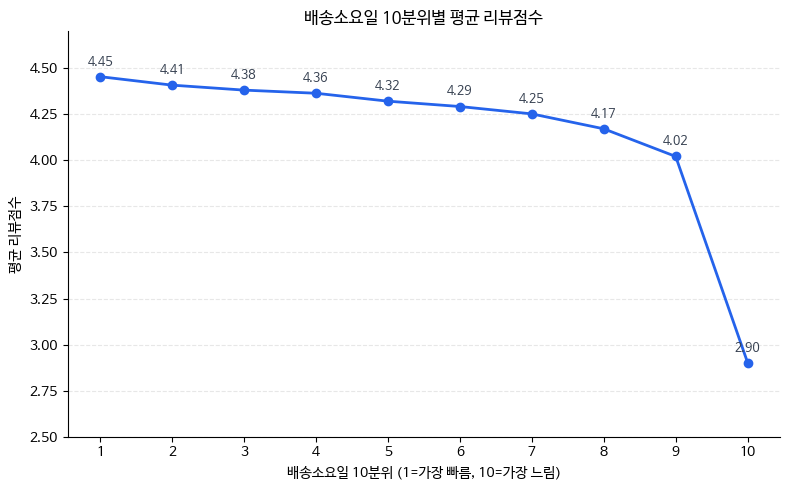

In [13]:
# 목적: H1 - 배송소요일 10분위별 평균 리뷰점수 추이 시각화 (단조감소 패턴 확인)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

x = h1_decile['배송소요일_10분위']
y = h1_decile['평균리뷰점수']

ax.plot(x, y, marker='o', markersize=6, linewidth=2, color='#2563EB')

# 각 점 위에 값 직접 라벨링
for xi, yi in zip(x, y):
    ax.annotate(f'{yi:.2f}', (xi, yi), textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=9, color='#374151')

ax.set_xlabel('배송소요일 10분위 (1=가장 빠름, 10=가장 느림)')
ax.set_ylabel('평균 리뷰점수')
ax.set_title('배송소요일 10분위별 평균 리뷰점수')
ax.set_xticks(range(1, 11))
ax.set_ylim(2.5, 4.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('h1_decile_trend.png', dpi=150)
plt.show()

## H1 검증 결과 — 시각화 확인 및 다음 단계

**관찰 (시각화 결과)**
- 배송소요일 1-8분위(4일-17일 구간)까지는 평균 리뷰점수가 4.45에서 4.17로 완만하게 감소
- 9분위에서 4.02로 한 번 꺾이고, 10분위(23-191일)에서 2.90으로 급격히 떨어짐 - 전체 감소분의 상당 부분이 마지막 1-2개 구간에 집중됨
- 즉 배송소요일이 늘어날수록 점진적으로 나빠지기보다, 극단적으로 오래 걸리는 소수 구간에서 리뷰점수가 크게 꺾이는 비선형 패턴

**결론**
- Pearson -0.34, Spearman -0.235(p<0.001), 10분위 단조감소 패턴까지 근거로 H1 **채택**
- 다만 감소가 선형적이지 않고 극단 구간에 쏠려있다는 건, "배송소요일 자체"보다 "정시성(예상 대비 지연 여부)"이 더 핵심적인 설명변수일 수 있다는 H2 가설과 연결되는 지점

**다음 단계**
H2(배송소요일 자체보다 정시성이 리뷰점수에 더 큰 영향을 미칠 것이다) 검증으로 진행

## H2 검증 — 배송 소요일 자체보다 정시성(지연 여부)이 리뷰점수에 더 큰 영향을 미칠 것이다

- 배송소요일(연속값)과 is_late(정시성, 이진값) 각각이 리뷰점수를 단독으로 얼마나 설명하는지(R²) 비교
- 배송소요일이 비슷한 구간(H1에서 만든 10분위) 안에서, 정시 배송과 지연 배송 간 평균 리뷰점수 차이를 비교 - 소요일을 어느 정도 고정한 상태에서 "지연 여부" 자체의 효과를 분리해서 확인

In [14]:
# 목적: H2 검증 - 배송소요일 vs 정시성(is_late) 중 어느 쪽이 리뷰점수를 더 잘 설명하는지 비교
query_h2_univariate = """
SELECT
    'delivery_days' AS 변수,
    REGR_R2(review_score, 배송소요일) AS r_squared
FROM base_df WHERE review_score IS NOT NULL
UNION ALL
SELECT
    'is_late' AS 변수,
    REGR_R2(review_score, CASE WHEN 지연일수 > 0 THEN 1 ELSE 0 END) AS r_squared
FROM base_df WHERE review_score IS NOT NULL
"""
h2_univariate = con.execute(query_h2_univariate).df()
print(h2_univariate)

# 목적: 배송소요일 10분위 내에서 정시 vs 지연 그룹 간 평균 리뷰점수 비교 (소요일을 고정한 상태에서 지연여부 효과 분리)
query_h2_controlled = """
WITH binned AS (
    SELECT 배송소요일, review_score,
        CASE WHEN 지연일수 > 0 THEN '지연' ELSE '정시' END AS 정시성,
        NTILE(10) OVER (ORDER BY 배송소요일) AS 배송소요일_10분위
    FROM base_df
    WHERE review_score IS NOT NULL
)
SELECT
    배송소요일_10분위,
    정시성,
    ROUND(AVG(배송소요일), 1) AS 평균소요일,
    ROUND(AVG(review_score), 3) AS 평균리뷰점수,
    COUNT(*) AS n
FROM binned
GROUP BY 배송소요일_10분위, 정시성
ORDER BY 배송소요일_10분위, 정시성
"""
h2_controlled = con.execute(query_h2_controlled).df()
h2_controlled

              변수  r_squared
0  delivery_days   0.116686
1        is_late   0.153571


,배송소요일_10분위,정시성,평균소요일,평균리뷰점수,n
0,1,정시,2.8,4.454,9565
1,1,지연,4.0,4.615,13
2,2,정시,5.1,4.408,9564
3,2,지연,5.5,4.154,13
4,3,정시,6.6,4.384,9535
5,3,지연,6.5,3.690,42
6,4,정시,7.9,4.368,9520
7,4,지연,7.9,3.667,57
8,5,정시,9.4,4.328,9518
9,5,지연,9.4,3.136,59


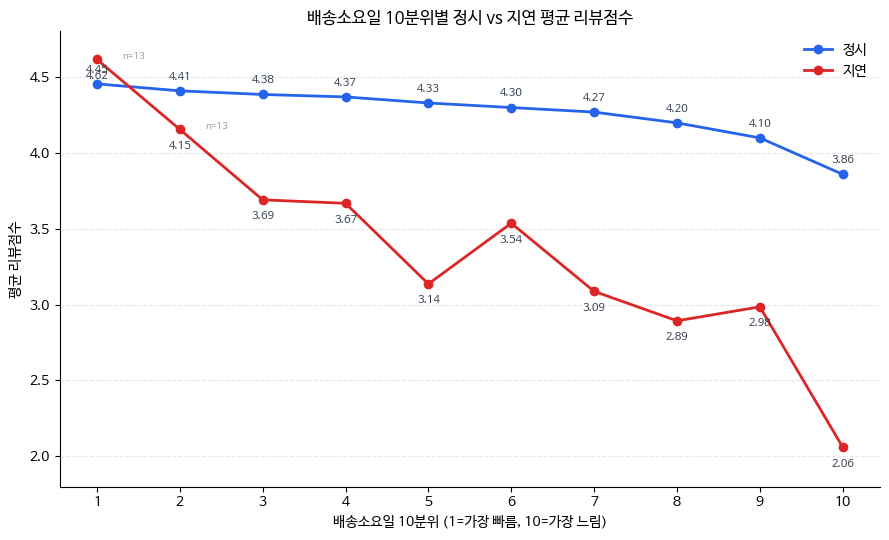

In [15]:
# 목적: H2 - 배송소요일 10분위별 정시 vs 지연 평균 리뷰점수 비교 시각화
import matplotlib.pyplot as plt

pivot = h2_controlled.pivot(index='배송소요일_10분위', columns='정시성', values='평균리뷰점수')
n_late = h2_controlled[h2_controlled['정시성'] == '지연'].set_index('배송소요일_10분위')['n']

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(pivot.index, pivot['정시'], marker='o', markersize=6, linewidth=2,
        color='#2563EB', label='정시')
ax.plot(pivot.index, pivot['지연'], marker='o', markersize=6, linewidth=2,
        color='#DC2626', label='지연')

for xi, yi in zip(pivot.index, pivot['정시']):
    ax.annotate(f'{yi:.2f}', (xi, yi), textcoords="offset points", xytext=(0, 8),
                ha='center', fontsize=8, color='#374151')
for xi, yi in zip(pivot.index, pivot['지연']):
    ax.annotate(f'{yi:.2f}', (xi, yi), textcoords="offset points", xytext=(0, -14),
                ha='center', fontsize=8, color='#374151')

# 표본이 적은 1-2분위 지연 포인트는 n 표시해서 노이즈 가능성 표시
for xi in [1, 2]:
    ax.annotate(f'n={n_late[xi]}', (xi, pivot.loc[xi, '지연']),
                textcoords="offset points", xytext=(18, 0), fontsize=7, color='#9CA3AF')

ax.set_xlabel('배송소요일 10분위 (1=가장 빠름, 10=가장 느림)')
ax.set_ylabel('평균 리뷰점수')
ax.set_title('배송소요일 10분위별 정시 vs 지연 평균 리뷰점수')
ax.set_xticks(range(1, 11))
ax.set_ylim(1.8, 4.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('h2_decile_ontime_vs_late.png', dpi=150)
plt.show()

## H2 검증 결과 — 관찰 및 다음 단계

**관찰**
- 전체 리뷰점수 설명력(R²) 비교: is_late(정시성) 0.154 > 배송소요일 0.117 - 이진값 하나(지연 여부)가 연속값(배송소요일)보다 더 많은 분산을 설명함
- 그래프로 보면 지연(빨강) 선이 전체 구간에서 정시(파랑) 선보다 뚜렷하게 아래에 위치 - 같은 소요일 구간이라도 지연 여부에 따라 격차가 큼
- 격차는 10분위에서 최대(정시 3.86 vs 지연 2.06, 1.8점 차이)로 벌어짐 - 절대적인 소요일보다 "예상보다 늦었는가"가 만족도를 더 크게 좌우
- 지연 선 5-6분위, 8-9분위 구간에서 살짝 오르내리는 굴곡이 있는데, 이 구간 표본이 58-197건 수준으로 상대적으로 적어서 노이즈일 가능성이 있음 - 전체 추세(우하향) 판단에는 영향 없음
- 1-2분위는 지연 표본이 13건씩뿐이라 노이즈로 보고 해석에서 제외

**결론**
H2 **채택** - 배송소요일 자체보다 정시성(지연 여부)이 리뷰점수에 더 큰 영향을 미침. R² 비교, 소요일을 고정한 상태의 그룹 비교, 시각화까지 모두 일관되게 같은 결론을 가리킴

**다음 단계**
H3(지연된 주문 안에서, 지연 폭이 클수록 리뷰점수가 더 낮아지는지) 검증으로 진행 - 지연일수 > 0인 케이스만 따로 떼서 지연 폭과 리뷰점수의 관계를 확인. 폭에 비례해서 점수가 계속 떨어지면 '비례효과', 폭과 상관없이 비슷하게 낮으면 '문턱효과(지연 여부 자체가 트리거)'로 해석

## H3 검증 — 배송 지연일수가 증가할수록 리뷰점수가 낮아질 것이다 (지연 케이스 한정)

- H2에서 지연 여부(이진) 자체가 소요일보다 중요하다는 게 확인됐으므로, H3는 전체 표본이 아니라 지연된 주문(지연일수 > 0)만 대상으로 지연 폭과 리뷰점수의 관계를 확인
- 지연일수와 review_score의 상관관계(Pearson, Spearman) 확인
- 지연일수를 구간화(1-3일, 4-7일, 8-14일, 15-30일, 31일 이상)해서 구간별 평균 리뷰점수가 폭에 비례해서 계속 떨어지는지, 아니면 일정 수준에서 평평해지는지(문턱효과) 확인

In [16]:
# 목적: H3 검증 - 지연된 주문(지연일수>0) 내에서 지연 폭이 클수록 리뷰점수가 더 낮아지는지 확인
from scipy import stats

query_h3_corr = """
SELECT
    COUNT(*) AS n,
    CORR(지연일수, review_score) AS pearson_상관계수,
    REGR_SLOPE(review_score, 지연일수) AS 기울기,
    REGR_R2(review_score, 지연일수) AS r_squared
FROM base_df
WHERE review_score IS NOT NULL AND 지연일수 > 0
"""
h3_corr = con.execute(query_h3_corr).df()
print(h3_corr)

h3_raw = con.execute(
    "SELECT 지연일수, review_score FROM base_df WHERE review_score IS NOT NULL AND 지연일수 > 0"
).df()
spearman_corr, spearman_p = stats.spearmanr(h3_raw['지연일수'], h3_raw['review_score'])
print(f"\nSpearman 상관계수: {spearman_corr:.4f} (p-value: {spearman_p:.2e})")

query_h3_bucket = """
SELECT
    CASE
        WHEN 지연일수 BETWEEN 1 AND 3 THEN '1) 1-3일'
        WHEN 지연일수 BETWEEN 4 AND 7 THEN '2) 4-7일'
        WHEN 지연일수 BETWEEN 8 AND 14 THEN '3) 8-14일'
        WHEN 지연일수 BETWEEN 15 AND 30 THEN '4) 15-30일'
        ELSE '5) 31일 이상'
    END AS 지연구간,
    ROUND(AVG(지연일수), 1) AS 평균지연일수,
    ROUND(AVG(review_score), 3) AS 평균리뷰점수,
    COUNT(*) AS n
FROM base_df
WHERE review_score IS NOT NULL AND 지연일수 > 0
GROUP BY 지연구간
ORDER BY 지연구간
"""
h3_bucket = con.execute(query_h3_bucket).df()
h3_bucket

      n  pearson_상관계수       기울기  r_squared
0  6350     -0.186456 -0.023853   0.034766

Spearman 상관계수: -0.4091 (p-value: 8.17e-255)


,지연구간,평균지연일수,평균리뷰점수,n
0,1) 1-3일,1.8,3.291,1852
1,2) 4-7일,5.5,2.103,1747
2,3) 8-14일,10.6,1.671,1446
3,4) 15-30일,20.4,1.609,1003
4,5) 31일 이상,49.8,1.993,302


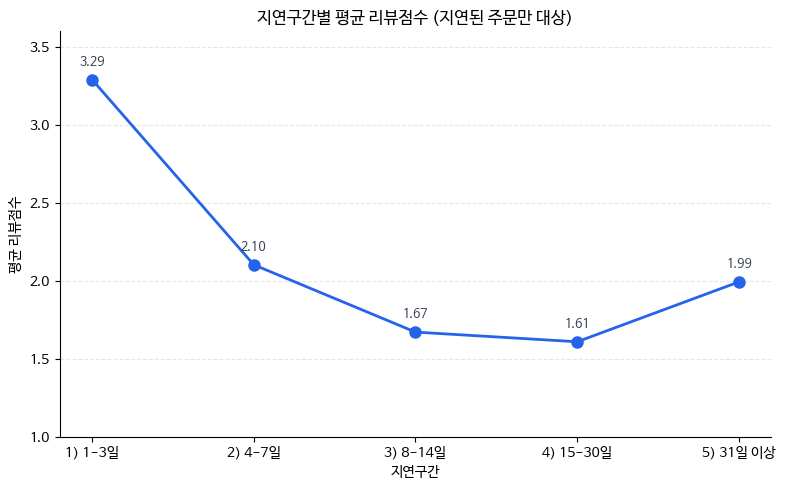

In [17]:
# 목적: H3 - 지연구간별 평균 리뷰점수 추이 시각화 (비선형 반등 패턴 확인)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

x = h3_bucket['지연구간']
y = h3_bucket['평균리뷰점수']

ax.plot(x, y, marker='o', markersize=8, linewidth=2, color='#2563EB')

for xi, yi in zip(x, y):
    ax.annotate(f'{yi:.2f}', (xi, yi), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9, color='#374151')

ax.set_xlabel('지연구간')
ax.set_ylabel('평균 리뷰점수')
ax.set_title('지연구간별 평균 리뷰점수 (지연된 주문만 대상)')
ax.set_ylim(1.0, 3.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('h3_delay_bucket_trend.png', dpi=150)
plt.show()

## H3 시각화 결과 — 31일 이상 반등 구간 원인 분석 착수

**관찰 (시각화 결과)**
- 1-3일(3.29)에서 시작해 15-30일(1.61)까지 급격히 하락하다가, 31일 이상 구간에서 1.99로 다시 반등 - U자형에 가까운 비선형 패턴이 그래프로도 뚜렷하게 확인됨
- 하락폭은 초반 구간(1-3일 → 4-7일, -1.19점)에서 가장 크고, 이후로는 하락폭이 점점 줄다가 마지막 구간에서 방향 자체가 바뀜

**결론**
시각화로도 비선형 반등 패턴 재확인. 다만 이 반등이 실제 고객 경험 개선(CS 개입/보상 처리) 때문인지, 앞서 발견한 09-19 케이스처럼 우리가 놓친 데이터 오류 때문인지는 아직 구분 안 됨 - 결론 내리기 전에 확인 필요

**다음 단계**
31일 이상 지연 구간(n=302)의 리뷰점수 실제 분포와, 도착일이 특정 날짜에 쏠려있는지(09-19 때와 같은 패턴)  검증

In [18]:
# 목적: 31일 이상 지연 구간(n=302)  검증 - 점수 분포 + 도착일 쏠림 여부
long_delay = base_df[(base_df['지연일수'] >= 31) & (base_df['review_score'].notnull())]

print("[31일 이상 지연 구간 리뷰점수 분포]")
print(long_delay['review_score'].value_counts().sort_index())

print("\n[도착일 상위 5개 - 특정 날짜 쏠림 확인]")
print(long_delay['order_delivered_customer_date'].dt.date.value_counts().head())

[31일 이상 지연 구간 리뷰점수 분포]
review_score
1    199
2     13
3     24
4     25
5     41
Name: count, dtype: Int64

[도착일 상위 5개 - 특정 날짜 쏠림 확인]
order_delivered_customer_date
2018-05-07    11
2018-04-19     8
2018-05-14     7
2018-05-03     6
2018-05-08     5
Name: count, dtype: int64


## H3 최종 판단 — 31일 이상 반등의 실제 원인

**관찰**
- 31일 이상 구간(n=302) 리뷰점수 분포: 1점 199건(65.9%), 2점 13건(4.3%), 3점 24건(7.9%), 4점 25건(8.3%), 5점 41건(13.6%)
- 평균만 보면 반등(1.99)했지만, 실제로는 압도적 다수(65.9%)가 여전히 최하점(1점)을 줌 - 다만 4-5점을 주는 소수 그룹(약 22%)이 존재해서 이 그룹이 평균을 끌어올린 이중분포(bimodal)에 가까운 형태
- 도착일 상위 5개는 2018-05-07(11건) 등으로 분산돼 있고, 09-19 때(하루 최대 285건)처럼 특정 날짜에 비정상적으로 몰리는 패턴은 없음 → 데이터 오류/일괄처리 흔적 아님

**결론**
31일 이상 구간의 평균 리뷰점수 반등은 데이터 오류가 아니라 실제 데이터. 다만 "경험이 개선됐다"는 뜻이 아니라, 대다수(66%)는 여전히 최악의 경험을 했고 소수(약 22%)의 높은 점수가 평균을 왜곡시킨 결과 - 이 구간은 평균보다 최빈값(1점)이 실제 고객 경험을 더 잘 대표함. 소수 그룹은 아마 CS 보상/환불 처리 등으로 최종 경험이 긍정적으로 전환됐을 것으로 추정(단순 추정, 데이터로 검증된 건 아님)

**다음 단계**
H4(배송 지연이 만족도에 미치는 영향의 크기는 지역별로 차이가 있을 것이다) 검증으로 진행

**H4 진행 전 - 지역별 주문 규모 확인**

지연이 리뷰점수에 미치는 영향(기울기)을 지역별로 비교하기 전에, 먼저 지역마다 주문 표본 자체가 얼마나 차이나는지 지도로 확인한다. 표본이 극단적으로 적은 지역의 기울기는 신뢰도가 낮을 수 있으므로, 이후 결과를 해석할 때 참고하기 위함이다.

In [19]:
# 목적: H4 진행 전 - 지역별(customer_state) 전체 주문건수 확인
query = """
SELECT customer_state, COUNT(*) AS 주문건수
FROM base_df
GROUP BY customer_state
ORDER BY 주문건수 DESC
"""
state_orders = con.execute(query).df()
print(state_orders)

   customer_state   주문건수
0              SP  40477
1              RJ  12348
2              MG  11347
3              RS   5341
4              PR   4923
5              SC   3543
6              BA   3251
7              DF   2080
8              ES   1993
9              GO   1954
10             PE   1592
11             CE   1278
12             PA    945
13             MT    886
14             MA    717
15             MS    701
16             PB    517
17             PI    474
18             RN    472
19             AL    396
20             SE    333
21             TO    274
22             RO    243
23             AM    144
24             AC     80
25             AP     66
26             RR     40


In [20]:
# 지역코드(customer_state)를 한글 지역명으로 변환 — 그래프/보고서 가독성용
state_kor_map = {
    'AC': '아크리주', 'AL': '알라고아스주', 'AP': '아마파주', 'AM': '아마조나스주',
    'BA': '바이아주', 'CE': '세아라주', 'DF': '연방구', 'ES': '이스피리투산투주',
    'GO': '고이아스주', 'MA': '마라냥주', 'MT': '마투그로수주', 'MG': '미나스제라이스주',
    'PA': '파라주', 'PB': '파라이바주', 'PR': '파라나주', 'PE': '페르남부쿠주',
    'PI': '피아우이주', 'RJ': '리우데자네이루주', 'RN': '히우그란지두노르치주',
    'RS': '히우그란지두술주', 'RO': '혼도니아주', 'RR': '호라이마주',
    'SC': '산타카타리나주', 'SP': '상파울루주', 'SE': '세르지피주',
    'MS': '마투그로수두술주', 'TO': '토칸칭스주'
}

state_orders['지역명'] = state_orders['customer_state'].map(state_kor_map)  # 코드 -> 한글명 매핑
state_orders_display = state_orders.rename(columns={'customer_state': '지역코드'})  # 컬럼명 한글화
state_orders_display[['지역코드', '지역명', '주문건수']]  # 출력 순서 정리

,지역코드,지역명,주문건수
0,SP,상파울루주,40477
1,RJ,리우데자네이루주,12348
2,MG,미나스제라이스주,11347
3,RS,히우그란지두술주,5341
4,PR,파라나주,4923
5,SC,산타카타리나주,3543
6,BA,바이아주,3251
7,DF,연방구,2080
8,ES,이스피리투산투주,1993
9,GO,고이아스주,1954


In [ ]:
# 목적: H4 진행 전 - 지역별 주문건수 지도
import numpy as np
import requests
import plotly.graph_objects as go

geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil_geo = requests.get(geojson_url).json()

state_orders['로그_주문건수'] = np.log10(state_orders['주문건수'])

# 주(state)별 대략적인 중심 좌표 (라벨 표시용)
state_centroids = {
    'AC': (-9.02, -70.81), 'AL': (-9.57, -36.78), 'AP': (1.41, -51.77),
    'AM': (-4.00, -63.00), 'BA': (-12.58, -41.70), 'CE': (-5.50, -39.32),
    'DF': (-15.80, -47.86), 'ES': (-19.18, -40.31), 'GO': (-15.83, -49.84),
    'MA': (-4.96, -45.27), 'MT': (-12.68, -56.92), 'MS': (-20.77, -54.79),
    'MG': (-18.51, -44.56), 'PA': (-3.92, -52.74), 'PB': (-7.24, -36.78),
    'PR': (-24.89, -51.55), 'PE': (-8.81, -36.95), 'PI': (-7.72, -42.73),
    'RJ': (-22.25, -42.66), 'RN': (-5.40, -36.95), 'RS': (-30.03, -53.25),
    'RO': (-10.83, -63.34), 'RR': (2.74, -62.08), 'SC': (-27.24, -50.22),
    'SP': (-22.19, -48.79), 'SE': (-10.57, -37.39), 'TO': (-10.25, -48.25),
}
state_centroids['RN'] = (-4.50, -35.50)  # 히우그란지두노르치주 — 살짝 오른쪽 위로
state_centroids['DF'] = (-15.00, -47.00)  # 연방구 — 살짝 오른쪽 위로 (고이아스주와 분리)

tick_counts = [100, 1000, 5000, 10000, 40000]
tickvals = [np.log10(v) for v in tick_counts]
ticktext = [f"{v:,}" for v in tick_counts]

fig = go.Figure()

fig.add_trace(go.Choropleth(
    geojson=brazil_geo,
    locations=state_orders['customer_state'],
    z=state_orders['로그_주문건수'],
    featureidkey="properties.sigla",
    colorscale=[[0, "#EFF6FF"], [0.5, "#60A5FA"], [1, "#1E3A8A"]],
    marker_line_color='white',
    marker_line_width=0.5,
    customdata=np.stack([state_orders['지역명'], state_orders['주문건수']], axis=-1),
    hovertemplate="%{customdata[0]}<br>주문건수: %{customdata[1]:,}<extra></extra>",
    colorbar=dict(title="주문건수", tickvals=tickvals, ticktext=ticktext)
))

label_lat = [state_centroids[s][0] for s in state_orders['customer_state']]
label_lon = [state_centroids[s][1] for s in state_orders['customer_state']]

threshold = np.log10(5000)  # 5,000건 이상인 진한 지역은 흰 글씨
text_colors = np.where(state_orders['로그_주문건수'] >= threshold, '#FFFFFF', '#1F2937')

fig.add_trace(go.Scattergeo(
    lat=label_lat,
    lon=label_lon,
    mode='text',
    text=state_orders['지역명'],
    textfont=dict(size=10, color=text_colors, family='Arial Black'),
    customdata=np.stack([state_orders['지역명'], state_orders['주문건수']], axis=-1),
    hovertemplate="%{customdata[0]}<br>주문건수: %{customdata[1]:,}<extra></extra>",
    showlegend=False
))

fig.update_geos(scope="south america", fitbounds="locations", visible=False)
fig.update_layout(
    title="지역별(customer_state) 주문건수 (로그 스케일 색상)",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    width=900,
    height=900
)
fig.show()

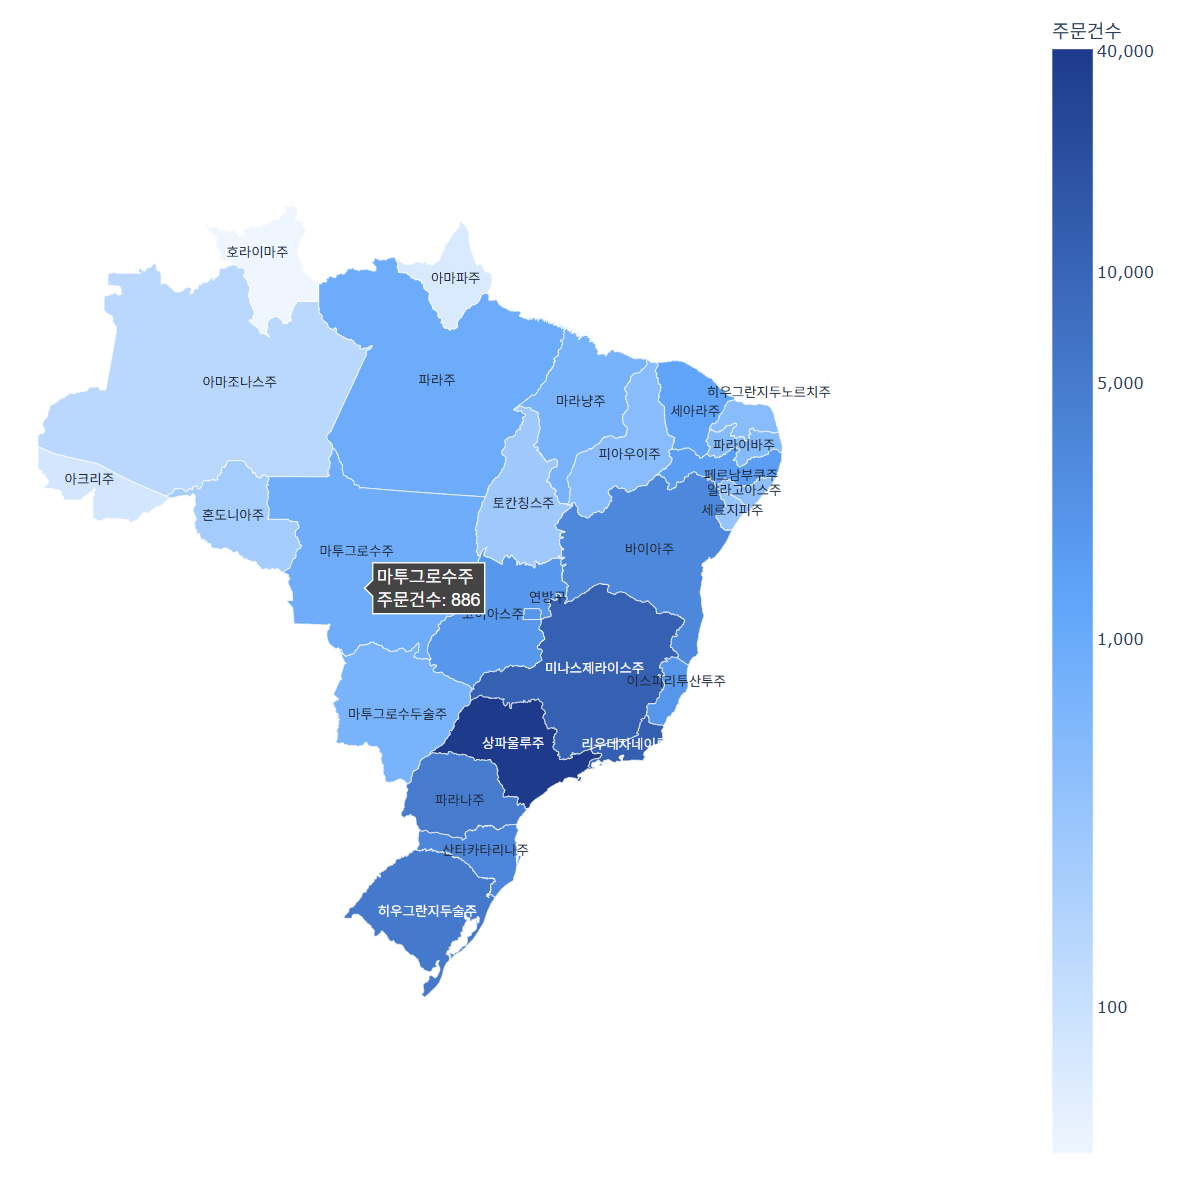

## H4 검증 — 배송 지연이 만족도에 미치는 영향의 크기는 지역별로 차이가 있을 것이다

- customer_state(고객 지역)별로 지연일수와 review_score의 관계(기울기)를 따로 계산해서, 이 기울기가 지역마다 얼마나 다른지 비교
- 표본이 너무 적은 지역은 노이즈가 커지므로, 주문 100건 이상인 지역만 대상으로 함
- 기울기가 더 음수인(가파른) 지역일수록 지연에 더 민감한 지역(같은 지연이라도 리뷰점수가 더 크게 떨어짐)

In [22]:
# 목적: H4 검증 - 지역(customer_state)별로 지연일수가 리뷰점수에 미치는 영향(기울기)이 다른지 확인
query_h4 = """
SELECT
    customer_state,
    COUNT(*) AS n_orders,
    ROUND(AVG(CASE WHEN 지연일수 > 0 THEN 1.0 ELSE 0.0 END), 3) AS 지연율,
    ROUND(AVG(지연일수), 1) AS 평균지연일수,
    ROUND(AVG(review_score), 3) AS 평균리뷰점수,
    REGR_SLOPE(review_score, 지연일수) AS 지연영향력_기울기,
    REGR_R2(review_score, 지연일수) AS r_squared,
    CORR(review_score, 지연일수) AS 상관계수
FROM base_df
WHERE customer_state IS NOT NULL AND review_score IS NOT NULL
GROUP BY customer_state
HAVING COUNT(*) >= 100
ORDER BY 지연영향력_기울기 ASC
"""

h4_region = con.execute(query_h4).df()
print(h4_region.shape)

# 지역코드를 한글 지역명으로 변환 + 남은 영어 컬럼명 한글화
h4_region['지역명'] = h4_region['customer_state'].map(state_kor_map)  # 코드 -> 한글명
h4_region = h4_region.rename(columns={
    'customer_state': '지역코드',
    'n_orders': '주문건수',
    'r_squared': 'R제곱'
})
h4_region = h4_region[['지역코드', '지역명', '주문건수', '지연율', '평균지연일수', '평균리뷰점수', '지연영향력_기울기', 'R제곱', '상관계수']]
h4_region

(24, 8)


,지역코드,지역명,주문건수,지연율,평균지연일수,평균리뷰점수,지연영향력_기울기,R제곱,상관계수
0,SE,세르지피주,332,0.145,-11.1,3.919,-0.060515,0.240388,-0.490293
1,PI,피아우이주,469,0.134,-12.0,3.994,-0.051878,0.196811,-0.443634
2,AL,알라고아스주,393,0.206,-9.0,3.855,-0.051871,0.204542,-0.452263
3,MS,마투그로수두술주,699,0.097,-11.0,4.157,-0.051866,0.139305,-0.373236
4,PA,파라주,932,0.106,-14.4,3.917,-0.048661,0.184858,-0.429951
5,CE,세아라주,1272,0.136,-11.0,3.947,-0.048053,0.223393,-0.472645
6,PE,페르남부쿠주,1578,0.094,-13.4,4.085,-0.046675,0.156672,-0.395818
7,RN,히우그란지두노르치주,469,0.087,-14.1,4.158,-0.046566,0.185720,-0.430952
8,SC,산타카타리나주,3516,0.080,-11.6,4.134,-0.046435,0.107225,-0.327453
9,RJ,리우데자네이루주,12209,0.119,-11.8,3.966,-0.044735,0.166824,-0.408441


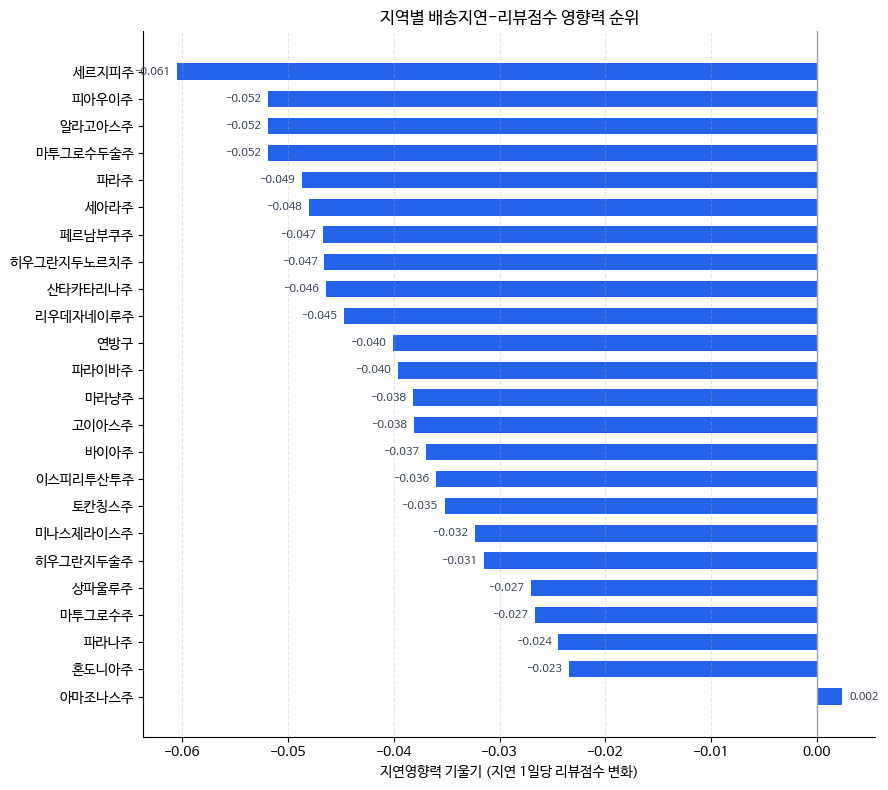

In [23]:
# 목적: H4 - 지역별 지연영향력 기울기 순위 시각화 (가로 막대그래프)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 8))

y_pos = range(len(h4_region))
ax.barh(y_pos, h4_region['지연영향력_기울기'], color='#2563EB', height=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(h4_region['지역명'])  # customer_state -> 지역명으로 변경
ax.invert_yaxis()  # 가장 민감한 지역이 위로 오게

for i, v in enumerate(h4_region['지연영향력_기울기']):
    ax.annotate(f'{v:.3f}', (v, i), textcoords="offset points",
                xytext=(5 if v >= 0 else -5, 0),
                ha='left' if v >= 0 else 'right', va='center',
                fontsize=8, color='#374151')

ax.axvline(0, color='#9CA3AF', linewidth=1)
ax.set_xlabel('지연영향력 기울기 (지연 1일당 리뷰점수 변화)')
ax.set_title('지역별 배송지연-리뷰점수 영향력 순위')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('h4_region_slope_ranking.png', dpi=150)
plt.show()

## H4 검증 결과

**관찰**
- 지역별 배송 지연 1일당 리뷰점수 하락폭(기울기)을 비교한 결과, 세르지피주가 -0.061로 하락폭이 가장 컸고 아마조나스주는 +0.002로 유일하게 양의 기울기를 보임
- 기울기 범위는 -0.061(세르지피주) ~ +0.002(아마조나스주)로, 절대값 기준 약 25배 차이
- 지연에 민감한 상위 지역(세르지피주, 피아우이주, 알라고아스주, 마투그로수두술주, 파라주, 세아라주)은 하락폭이 크게 몰려 있는 반면, 둔감한 지역(아마조나스주, 혼도니아주, 파라나주, 마투그로수주, 상파울루주)은 하락폭이 거의 없거나 오히려 양수
- 상파울루주, 미나스제라이스주처럼 주문량 자체가 많은 대형 시장은 오히려 기울기가 완만한 편으로, 거래량 규모와 지연 민감도가 비례하지 않음
- 막대그래프로 보니 24개 지역 순위 전체가 한눈에 들어오고, 특히 아마조나스주만 막대가 반대 방향(양수)으로 튀어나와 있어서 부호가 뒤집힌 지역이 이 지역 하나뿐이라는 게 표로 볼 때보다 훨씬 명확하게 드러남

**결론**
- H4 채택: 배송 지연이 리뷰점수에 미치는 영향력의 크기는 지역별로 뚜렷한 차이가 있고, 그 차이가 최대 약 25배에 달함
- "지연이 나쁘다"는 전체 평균(H1, H2)만으로는 놓치는 정보로, 실무적으로는 "어느 지역에서 지연이 특히 치명적인가"를 아는 게 더 중요한 인사이트
- 아마조나스주는 지연과 리뷰점수가 음의 관계로 나타나지 않는다는 점에서 다른 지역과 다른 맥락(표본 크기, 다른 변수의 영향 등)이 있을 가능성이 있으나, 이번 분석 범위에서는 추가로 확인하지 않음(단순 관찰 수준)

**다음 단계**
- H5로 이동: 지연의 원인을 판매자-구매자 거리로 가정하고, 두 위치 간 거리(haversine)와 지연일수의 관계를 확인

# H5. 판매자-구매자 거리 - 배송 지연에 미치는 영향

**목적**
- H4에서 확인한 지역별 지연 민감도 차이가 실제로는 판매자-구매자 간 물리적 거리 차이에서 비롯된 것인지 확인한다
- 판매자가 특정 지역에 편중돼 있어 지역별로 구매자-판매자 거리 자체가 다르게 나타나는지 먼저 시각적으로 확인한다
- 거리가 멀수록 운송 시간이 늘어나 지연 가능성이 높아질 것으로 예상한다
- 거리와 지연일수의 관계를 정량적으로 확인하고, 필요하면 지역별 거리 분포 차이도 함께 살펴본다

**방법**
1. 구매자/판매자 위치를 지도에 산점도로 시각화해 지리적 분포와 편중 여부를 확인한다
2. olist_geolocation_dataset에서 customer_zip_code_prefix, seller_zip_code_prefix별 평균 위경도를 구한다
3. 각 주문의 구매자-판매자 위경도로 haversine 공식을 이용해 두 지점 간 거리(km)를 계산한다
4. 거리와 배송소요일, 거리와 리뷰점수 각각의 상관관계 및 회귀 기울기를 확인한다
5. 거리를 구간(분위)으로 나눠 구간별 배송소요일·리뷰점수 추이도 함께 확인한다
6. 필요하면 지역(customer_state)별로 평균 거리 차이가 있는지도 함께 확인한다

In [43]:
# 목적: geolocation 파일 경로 등록 + zip_code_prefix별 평균 위경도 계산
geolocation_path = DATA_PATH + '/olist_geolocation_dataset.csv'

query = """
SELECT
    geolocation_zip_code_prefix AS zip_code_prefix,
    AVG(geolocation_lat) AS lat,
    AVG(geolocation_lng) AS lng
FROM read_csv_auto('{}')
GROUP BY geolocation_zip_code_prefix
""".format(geolocation_path)

geo_avg = con.execute(query).df()
print(geo_avg.shape)
geo_avg.head()

(19015, 3)


,zip_code_prefix,lat,lng
0,05528,-23.594618,-46.757242
1,05583,-23.583275,-46.787116
2,05539,-23.575938,-46.727216
3,05547,-23.593289,-46.772505
4,05549,-23.597135,-46.766158


In [44]:
# 목적: 구매자/판매자 위치 분포 확인용 데이터 준비
customer_locs = con.execute("""
SELECT c.customer_state AS state, g.lat, g.lng
FROM read_csv_auto('{}') c
JOIN geo_avg g ON c.customer_zip_code_prefix = g.zip_code_prefix
""".format(customers_path)).df()

seller_locs = con.execute("""
SELECT s.seller_state AS state, g.lat, g.lng
FROM read_csv_auto('{}') s
JOIN geo_avg g ON s.seller_zip_code_prefix = g.zip_code_prefix
""".format(sellers_path)).df()

print(customer_locs.shape, seller_locs.shape)

(99163, 3) (3088, 3)


In [ ]:
# 목적: 구매자 위치 분포 - PAPER 배경 지도(고정 확대) 위 산점도(SIGNAL) + 지역명 라벨
def make_base_fig(title):
    fig = go.Figure()
    fig.add_trace(go.Choropleth(
    geojson=brazil_geo,
    locations=list(state_centroids.keys()),
    z=[1] * len(state_centroids),
    featureidkey="properties.sigla",
    colorscale=[[0, "#F2F2EA"], [1, "#F2F2EA"]],  # PAPER
    marker_line_color='#5C5C50',
    marker_line_width=1.2,
    showscale=False,
    hoverinfo='skip'
))
    fig.update_geos(
        scope="south america",
        lataxis_range=[-35, 6],
        lonaxis_range=[-75, -32],
        visible=False,
        projection_type="mercator",
        bgcolor='#F2F2EA'
    )
    fig.update_layout(
        title=title,
        margin={"r": 0, "t": 40, "l": 0, "b": 0},
        width=700, height=700,
        paper_bgcolor='#F2F2EA',
        plot_bgcolor='#F2F2EA',
        font_color='#030303'
    )
    return fig

def add_state_labels(fig):
    fig.add_trace(go.Scattergeo(
        lat=[state_centroids[s][0] for s in state_centroids],
        lon=[state_centroids[s][1] for s in state_centroids],
        mode='text',
        text=[state_kor_map[s] for s in state_centroids],
        textfont=dict(size=9, color='#030303', family='Arial Black'),
        showlegend=False,
        hoverinfo='skip'
    ))
    return fig

fig_cust = make_base_fig(f"구매자 위치 분포 ({len(customer_locs):,}건)")
fig_cust.add_trace(go.Scattergeo(
    lat=customer_locs['lat'], lon=customer_locs['lng'],
    mode='markers', marker=dict(size=3, color='#8FBF00', opacity=0.5),
    hoverinfo='skip'
))
fig_cust = add_state_labels(fig_cust)
fig_cust.show()

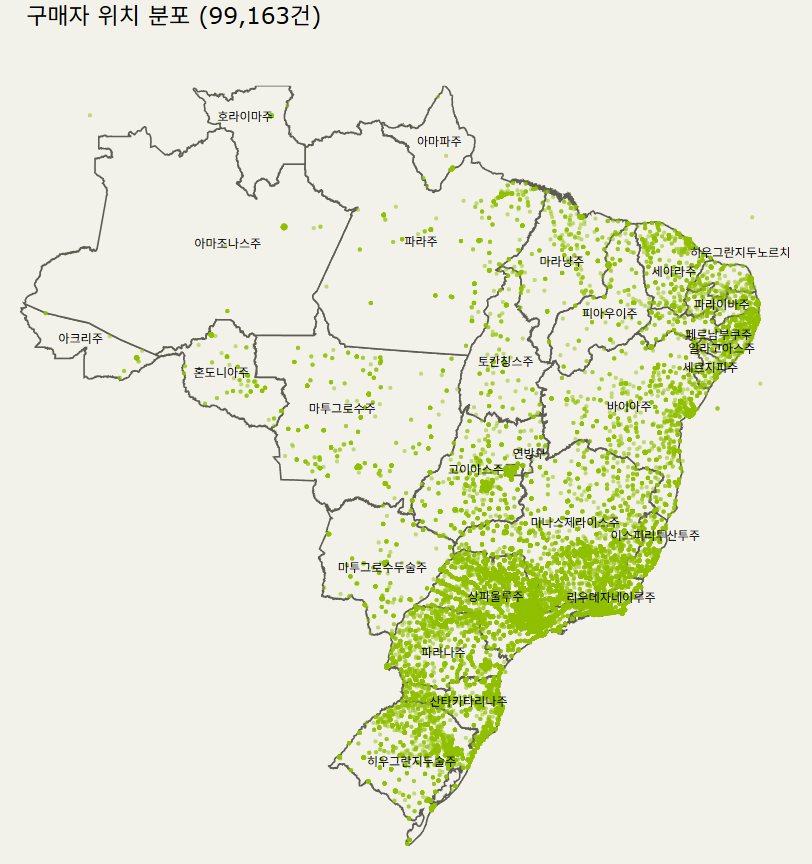

In [ ]:
# 목적: 판매자 위치 분포 - PAPER 배경 지도(고정 확대) 위 산점도(레드) + 지역명 라벨
fig_sell = make_base_fig(f"판매자 위치 분포 ({len(seller_locs):,}건)")
fig_sell.add_trace(go.Scattergeo(
    lat=seller_locs['lat'], lon=seller_locs['lng'],
    mode='markers', marker=dict(size=5, color='#D62728', opacity=0.7),
    hoverinfo='skip'
))
fig_sell = add_state_labels(fig_sell)
fig_sell.show()

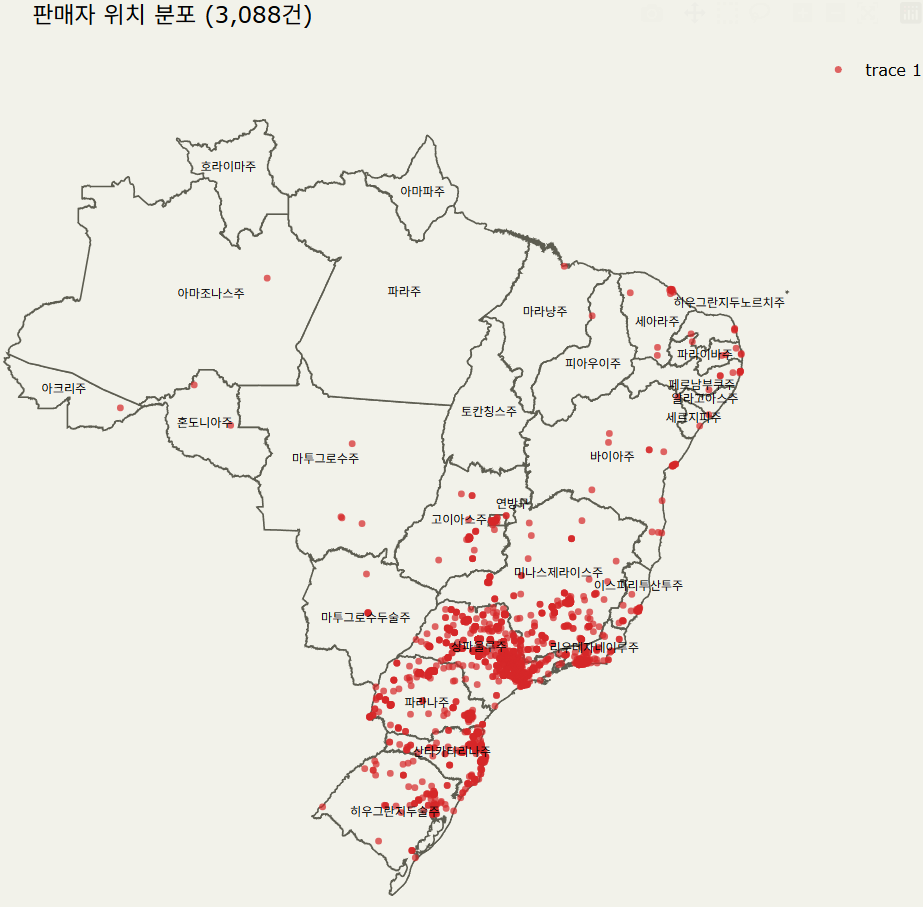

In [ ]:
# 목적: 구매자(SIGNAL) vs 판매자(레드) 위치 분포 비교 - 지역명 라벨 포함
fig_both = make_base_fig("구매자 vs 판매자 위치 분포 비교")
fig_both.add_trace(go.Scattergeo(
    lat=customer_locs['lat'], lon=customer_locs['lng'],
    mode='markers', marker=dict(size=3, color='#8FBF00', opacity=0.4),
    name=f"구매자 ({len(customer_locs):,})"
))
fig_both.add_trace(go.Scattergeo(
    lat=seller_locs['lat'], lon=seller_locs['lng'],
    mode='markers', marker=dict(size=5, color='#D62728', opacity=0.8),
    name=f"판매자 ({len(seller_locs):,})"
))
fig_both = add_state_labels(fig_both)
fig_both.update_layout(showlegend=True, legend=dict(bgcolor='#F2F2EA', font=dict(color='#030303')))
fig_both.show()

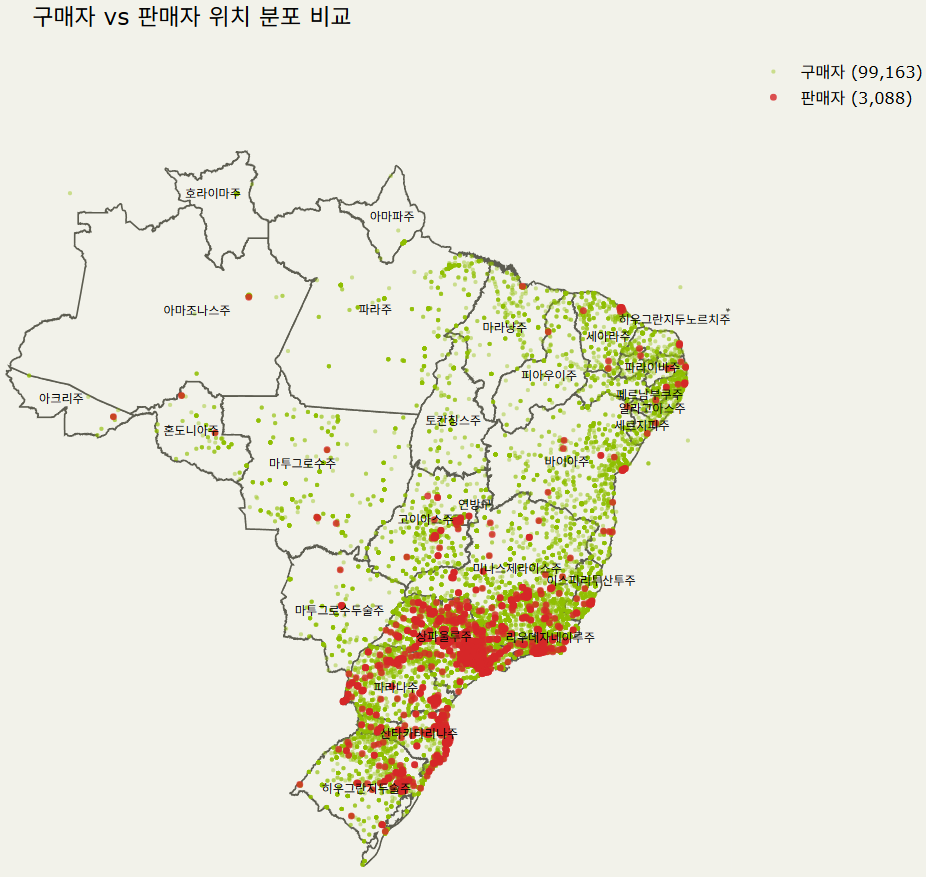

**관찰 - 구매자/판매자 위치 분포**

- 구매자는 전국에 넓게 퍼져 있지만 남동부(상파울루주·리우데자네이루주·미나스제라이스주)에 뚜렷하게 밀집
- 판매자는 구매자보다 훨씬 좁은 범위에 집중 - 특히 상파울루주 한 곳에 대부분 몰려있고, 북부·중서부·북동부 지역엔 거의 없음
- 구매자 수(99,163) 대비 판매자 수(3,088)로 약 32배 차이 - 판매자 시장 자체가 소수 지역에 편중된 구조
- 판매자가 희소한 북동부·북부·중서부 지역의 구매자는 구조적으로 먼 거리의 판매자와 거래할 수밖에 없음 → H4에서 확인한 지역별 지연 민감도 차이가 이 지리적 불균형에서 비롯됐을 가능성을 뒷받침

**다음 단계**
- 전체 주문의 거리를 계산하기 전에, 판매자가 밀집된 남동부와 판매자가 희소한 북동부의 지연율·리뷰점수 차이를 먼저 비교해 지리적 편중이 실제 지연 차이로 이어지는지 확인한다

In [57]:
# 목적: 판매자 밀집 지역(남동부) vs 판매자 희소 지역(북동부) 지연/리뷰 비교
query = """
SELECT
    CASE
        WHEN 지역코드 IN ('SP','RJ','MG','ES') THEN '남동부(판매자 밀집)'
        WHEN 지역코드 IN ('MA','PI','CE','RN','PB','PE','AL','SE','BA') THEN '북동부(판매자 희소)'
    END AS 권역,
    SUM(주문건수) AS 주문건수,
    ROUND(SUM(지연율 * 주문건수) / SUM(주문건수), 4) AS 지연율,
    ROUND(SUM(평균지연일수 * 주문건수) / SUM(주문건수), 2) AS 평균지연일수,
    ROUND(SUM(평균리뷰점수 * 주문건수) / SUM(주문건수), 3) AS 평균리뷰점수
FROM h4_region
WHERE 지역코드 IN ('SP','RJ','MG','ES','MA','PI','CE','RN','PB','PE','AL','SE','BA')
GROUP BY 권역
ORDER BY 권역
"""
h5_region_compare = con.execute(query).df()
h5_region_compare

,권역,주문건수,지연율,평균지연일수,평균리뷰점수
0,남동부(판매자 밀집),65704.0,0.0599,-11.60,4.180
1,북동부(판매자 희소),8962.0,0.1237,-11.59,3.972


**관찰 - 판매자 밀집/희소 지역 비교**

- 판매자가 밀집한 남동부는 지연율 5.99%, 평균리뷰점수 4.180
- 판매자가 희소한 북동부는 지연율 12.37%(남동부의 약 2배), 평균리뷰점수 3.972
- 권역 단위로 봐도 판매자와 가까운 지역이 지연이 적고 리뷰가 높은 경향이 뚜렷함

**결론**

- 판매자 분포와 지연/리뷰 사이에 방향성 있는 차이가 확인됨 - 다만 권역 평균 비교만으로는 다른 지역 특성이 섞여있을 수 있어 인과로 단정하기엔 근거가 약함
- 이 관계가 단순히 "지역" 때문이 아니라 "거리" 자체에서 오는 것인지 확인하기 위해 주문 단위로 실제 거리를 계산해 검증한다

**분석 - 주문 단위 거리와 배송소요일/리뷰점수의 관계**

- 목적: 권역 비교에서 확인한 지연/리뷰 차이가 실제로 거리 자체 때문인지, 주문 단위의 연속적인 거리값으로 직접 검증한다
- 방법: h5_base(주문별 distance_km, 배송소요일, 리뷰점수)를 이용해 거리-배송소요일, 거리-리뷰점수 각각의 상관관계를 피어슨과 스피어만 두 지표로 함께 확인한다
- 두 지표를 함께 쓰는 이유: 피어슨은 직선적인 관계 강도만 측정하는 반면, 스피어만은 순위 기반이라 관계가 곡선(비선형)이어도 단조증가/감소 패턴이면 강하게 잡아낸다. 두 값을 비교하면 "관계가 원래 약한 것"과 "관계는 강한데 비선형이라 피어슨이 저평가한 것"을 구분할 수 있다

In [67]:
# 목적: 주문별 구매자-판매자 거리(haversine) + 배송소요일 + 리뷰점수 계산
query = """
WITH geo_avg AS (
    SELECT geolocation_zip_code_prefix AS zip_code_prefix,
           AVG(geolocation_lat) AS lat, AVG(geolocation_lng) AS lng
    FROM read_csv_auto('{geo}')
    GROUP BY geolocation_zip_code_prefix
),
customer_geo AS (
    SELECT c.customer_id, c.customer_state, g.lat AS cust_lat, g.lng AS cust_lng
    FROM read_csv_auto('{cust}') c
    JOIN geo_avg g ON c.customer_zip_code_prefix = g.zip_code_prefix
),
seller_geo AS (
    SELECT s.seller_id, g.lat AS seller_lat, g.lng AS seller_lng
    FROM read_csv_auto('{sell}') s
    JOIN geo_avg g ON s.seller_zip_code_prefix = g.zip_code_prefix
),
order_seller AS (
    SELECT DISTINCT order_id, seller_id
    FROM read_csv_auto('{items}')
),
review_avg AS (
    SELECT order_id, AVG(review_score) AS review_score
    FROM read_csv_auto('{reviews}')
    GROUP BY order_id
)
SELECT
    o.order_id,
    cg.customer_state,
    DATEDIFF('day', o.order_purchase_timestamp, o.order_delivered_customer_date) AS 배송소요일,
    r.review_score AS 리뷰점수,
    6371 * ACOS(
        COS(RADIANS(cg.cust_lat)) * COS(RADIANS(sg.seller_lat)) * COS(RADIANS(sg.seller_lng) - RADIANS(cg.cust_lng))
        + SIN(RADIANS(cg.cust_lat)) * SIN(RADIANS(sg.seller_lat))
    ) AS distance_km
FROM read_csv_auto('{orders}') o
JOIN customer_geo cg ON o.customer_id = cg.customer_id
JOIN order_seller os ON o.order_id = os.order_id
JOIN seller_geo sg ON os.seller_id = sg.seller_id
LEFT JOIN review_avg r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL
""".format(
    geo=geolocation_path, cust=customers_path, sell=sellers_path,
    items=order_items_path, reviews=order_reviews_path, orders=orders_path
)

h5_base = con.execute(query).df()

# 지역코드 -> 한글 지역명 매핑 + 컬럼명 정리
h5_base['지역명'] = h5_base['customer_state'].map(state_kor_map)
h5_base = h5_base.rename(columns={'customer_state': '지역코드'})
h5_base = h5_base[['order_id', '지역코드', '지역명', '배송소요일', '리뷰점수', 'distance_km']]

print(h5_base.shape)
h5_base.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(97325, 6)


,order_id,지역코드,지역명,배송소요일,리뷰점수,distance_km
0,19a446583991325bc207214763eea124,SP,상파울루주,2,5.0,15.430824
1,f46e4c3b10d88caacf23b8ee4d674d7e,RJ,리우데자네이루주,7,5.0,330.720487
2,ebb17d52f687e249ea4c82b179752cdd,SP,상파울루주,6,1.0,45.145886
3,0e9a5de04c76a97588efe7f216942de2,SP,상파울루주,7,5.0,327.746202
4,f9c44da06151c190a9a6c9c712873d10,SP,상파울루주,7,5.0,6.554595


In [59]:
# 목적: 거리(distance_km)와 배송소요일, 리뷰점수 간 상관관계 확인
query = """
SELECT
    ROUND(CORR(distance_km, 배송소요일), 3) AS 피어슨_거리_배송소요일,
    ROUND(CORR(distance_km, 리뷰점수), 3) AS 피어슨_거리_리뷰점수,
    ROUND(REGR_SLOPE(배송소요일, distance_km), 4) AS 회귀기울기_배송소요일,
    ROUND(REGR_R2(배송소요일, distance_km), 3) AS R제곱_배송소요일
FROM h5_base
WHERE 리뷰점수 IS NOT NULL
"""
h5_corr = con.execute(query).df()
h5_corr

,피어슨_거리_배송소요일,피어슨_거리_리뷰점수,회귀기울기_배송소요일,R제곱_배송소요일
0,0.396,-0.058,0.0063,0.157


In [60]:
# 목적: 거리-배송소요일, 거리-리뷰점수 스피어만 상관관계 확인
from scipy.stats import spearmanr

valid = h5_base.dropna(subset=['리뷰점수'])

corr_delivery, _ = spearmanr(valid['distance_km'], valid['배송소요일'])
corr_review, _ = spearmanr(valid['distance_km'], valid['리뷰점수'])

print(f"스피어만 거리-배송소요일: {corr_delivery:.3f}")
print(f"스피어만 거리-리뷰점수: {corr_review:.3f}")

스피어만 거리-배송소요일: 0.541
스피어만 거리-리뷰점수: -0.065


In [62]:
# 목적: 거리 10분위별 평균배송소요일 및 평균리뷰점수 추이 확인
query = """
WITH bucketed AS (
    SELECT
        NTILE(10) OVER (ORDER BY distance_km) AS 거리_10분위,
        distance_km, 배송소요일, 리뷰점수
    FROM h5_base
    WHERE 리뷰점수 IS NOT NULL
)
SELECT
    거리_10분위,
    COUNT(*) AS 주문건수,
    ROUND(MIN(distance_km), 1) AS 최소거리,
    ROUND(MAX(distance_km), 1) AS 최대거리,
    ROUND(AVG(distance_km), 1) AS 평균거리,
    ROUND(AVG(배송소요일), 2) AS 평균배송소요일,
    ROUND(AVG(리뷰점수), 3) AS 평균리뷰점수
FROM bucketed
GROUP BY 거리_10분위
ORDER BY 거리_10분위
"""
h5_decile = con.execute(query).df()
h5_decile

,거리_10분위,주문건수,최소거리,최대거리,평균거리,평균배송소요일,평균리뷰점수
0,1,9667,0.0,34.6,17.0,5.88,4.283
1,2,9667,34.6,116.9,72.6,7.19,4.237
2,3,9667,116.9,277.1,190.8,9.78,4.249
3,4,9667,277.1,347.9,316.9,11.85,4.095
4,5,9667,347.9,433.8,384.8,12.19,4.148
5,6,9667,433.8,529.7,481.7,12.44,4.128
6,7,9666,529.7,694.2,601.8,14.04,4.073
7,8,9666,694.2,875.9,791.4,14.32,4.102
8,9,9666,875.9,1454.5,1086.4,16.15,4.079
9,10,9666,1454.5,8677.9,2056.1,20.16,3.983


**관찰 - 주문 단위 거리와 배송소요일/리뷰점수의 관계**

- 거리-배송소요일 상관관계: 피어슨 0.396, 스피어만 0.541 - 거리가 멀수록 배송이 오래 걸리는 경향이 뚜렷함
- 거리-리뷰점수 상관관계: 피어슨 -0.058, 스피어만 -0.065 - 상관관계 자체는 약함
- 거리 10분위별로 보면 평균배송소요일은 1분위 5.88일에서 10분위 20.16일까지 전 구간에서 꾸준히 증가
- 평균리뷰점수는 1-9분위까지 4.07-4.28 사이에서 큰 변화 없이 유지되다가 10분위(최상위 10%, 1,454km 이상)에서만 3.983으로 눈에 띄게 하락
- 즉 거리는 배송소요일에는 전 구간에 걸쳐 확실한 영향을 주지만, 리뷰점수는 극단적으로 먼 거리(최상위 10%)에서만 약하게 영향을 줌 - 권역 비교에서 본 리뷰점수 차이(4.180 vs 3.972)도 이 "극단적으로 먼 주문 비중" 차이로 설명 가능

**결론**

- H5 채택: 판매자-구매자 거리는 배송소요일에 전 구간에 걸쳐 확실한 영향을 미친다
- 리뷰점수에 대한 영향은 제한적 - 거리가 늘어난다고 꾸준히 나빠지는 게 아니라 극단적으로 먼 주문(최상위 10%)에서만 나타남
- 종합하면 H4에서 발견한 지역별 지연 민감도 차이는 상당 부분 판매자-구매자 물리적 거리 차이에서 비롯된 것으로 판단됨

**다음 단계**

- Olist는 마켓플레이스 구조상 판매자 위치를 통제할 수 없으므로, 판매자가 희소해 거리가 먼 지역의 배송 지연을 줄이려면 회사가 통제 가능한 변수인 물류센터/거점창고 입지를 데이터 기반으로 제안한다
- 물류센터 개선 방식은 크게 재고 사전배치형(풀필먼트)과 중계거점형(크로스독)으로 나뉘는데, 어떤 방식이 적합한지 판단하려면 먼저 판매자 희소 지역과 밀집 지역의 주문 카테고리 구성 차이를 확인해야 한다
- 카테고리 구성이 비슷하면 카테고리와 무관하게 거리 자체가 원인이라는 뜻이므로 크로스독 모델이 적합하고, 특정 카테고리가 먼 지역에 쏠려 있다면 그 카테고리 중심의 풀필먼트 옵션도 함께 검토한다

In [64]:
# 목적: 판매자 밀집(남동부) vs 희소(북동부) 지역의 주문 카테고리 구성 비교
products_path = DATA_PATH + '/olist_products_dataset.csv'
category_path = DATA_PATH + '/product_category_name_translation.csv'

query = """
WITH region AS (
    SELECT customer_id,
        CASE
            WHEN customer_state IN ('SP','RJ','MG','ES') THEN '남동부(판매자 밀집)'
            WHEN customer_state IN ('MA','PI','CE','RN','PB','PE','AL','SE','BA') THEN '북동부(판매자 희소)'
        END AS 권역
    FROM read_csv_auto('{cust}')
),
items_cat AS (
    SELECT oi.order_id, COALESCE(t.product_category_name_english, p.product_category_name) AS 카테고리
    FROM read_csv_auto('{items}') oi
    JOIN read_csv_auto('{prod}') p ON oi.product_id = p.product_id
    LEFT JOIN read_csv_auto('{cat}') t ON p.product_category_name = t.product_category_name
)
SELECT
    r.권역,
    ic.카테고리,
    COUNT(*) AS 주문상품수
FROM read_csv_auto('{orders}') o
JOIN region r ON o.customer_id = r.customer_id
JOIN items_cat ic ON o.order_id = ic.order_id
WHERE r.권역 IS NOT NULL
GROUP BY r.권역, ic.카테고리
""".format(
    cust=customers_path, items=order_items_path, prod=products_path,
    cat=category_path, orders=orders_path
)

h5_category = con.execute(query).df()
print(h5_category.shape)
h5_category.head()

(144, 3)


,권역,카테고리,주문상품수
0,남동부(판매자 밀집),furniture_decor,5715
1,남동부(판매자 밀집),perfumery,2404
2,남동부(판매자 밀집),health_beauty,6519
3,남동부(판매자 밀집),books_technical,185
4,남동부(판매자 밀집),fashion_bags_accessories,1376


In [69]:
# 목적: 지역별 카테고리 비중 차이 비교 (북동부에서 상대적으로 많이/적게 팔리는 카테고리)
import pandas as pd

h5_category['비중'] = h5_category.groupby('권역')['주문상품수'].transform(lambda x: x / x.sum())

pivot = h5_category.pivot(index='카테고리', columns='권역', values='비중').fillna(0)
pivot['차이(북동부-남동부)'] = pivot['북동부(판매자 희소)'] - pivot['남동부(판매자 밀집)']
pivot = pivot.sort_values('차이(북동부-남동부)', ascending=False)

pd.set_option('display.float_format', '{:.2%}'.format)
result = pd.concat([pivot.head(10), pivot.tail(10)])
result

권역,남동부(판매자 밀집),북동부(판매자 희소),차이(북동부-남동부)
카테고리,,,
telephony,3.47%,6.62%,3.15%
health_beauty,8.42%,10.94%,2.52%
watches_gifts,5.09%,7.53%,2.44%
cool_stuff,3.12%,3.94%,0.82%
auto,3.60%,4.42%,0.82%
electronics,2.35%,2.79%,0.44%
computers,0.13%,0.55%,0.41%
office_furniture,1.50%,1.89%,0.39%
fashion_bags_accessories,1.78%,2.01%,0.23%


**관찰 - 지역별 카테고리 구성 비교**

- 통신기기(telephony, +3.15%p), 헬스&뷰티(health_beauty, +2.52%p), 시계&선물용품(watches_gifts, +2.44%p), 가전제품(electronics, +0.44%p), 컴퓨터(computers, +0.41%p) - 북동부에서 비중이 더 높은 카테고리들은 대부분 작고 가볍고 단가 대비 부피가 작은 상품
- 침구/욕실/테이블용품(bed_bath_table, -5.07%p), 생활용품(housewares, -2.82%p), 가구/인테리어소품(furniture_decor, -1.26%p) - 남동부에서 비중이 더 높은 카테고리들은 부피가 크고 무거운 가정용품/가구류
- 차이의 절대 크기는 대부분 1-3%p 수준으로 극단적이지 않음 - 카테고리 구성이 지역별로 완전히 다르다기보다는 일부 품목에서 경향성이 나타나는 정도

**결론**

- 카테고리 구성 차이가 크지 않으므로, 지연 문제의 근본 원인은 "특정 카테고리"가 아니라 거리 자체로 판단됨 → 카테고리와 무관하게 작동하는 중계거점형(크로스독) 모델이 기본 방향으로 적합
- 다만 북동부에서 비중이 높은 카테고리(통신기기·헬스&뷰티·시계&선물용품)는 공교롭게도 작고 가벼워 재고 사전배치(풀필먼트)에도 적합한 특성을 가짐 - 크로스독을 기본으로 하되, 이 상위 카테고리들은 추후 재고 사전배치 옵션으로 확장 검토 가능

# 액션 제안 - 물류센터 입지 후보 도출

**배경**
- H4·H5에서 확인한 지역별 배송 지연 격차는 판매자-구매자 물리적 거리에서 상당 부분 비롯됨
- Olist는 마켓플레이스 구조상 판매자 위치를 통제할 수 없으므로, 회사가 통제 가능한 변수인 물류센터/거점창고 입지를 데이터 기반으로 제안한다
- 카테고리 구성 차이는 크지 않아, 중계거점형(크로스독) 모델을 기본 방향으로 하고 입지를 선정한다

**방법**
1. 판매자 희소·지연 심한 지역(북동부)의 주문 밀집도를 거리가중 중심점(center of gravity)으로 계산해 이론적 최적 위치를 확인한다
2. 북동부 내 기존 물류 인프라(항구·공항)를 갖춘 실제 후보 도시들을 선정한다
3. 각 후보 도시에서 북동부 전체 주문지까지의 평균 거리를 계산해 거리 효율을 비교한다
4. 인구 규모와 기존 인프라 여건을 함께 고려해 최종 후보 도시를 추천한다

In [70]:
# 목적: 북동부 주문 밀집도 기반 거리가중 중심점(이론적 최적 입지) 계산
ne_states = ['MA','PI','CE','RN','PB','PE','AL','SE','BA']
ne_customers = customer_locs[customer_locs['state'].isin(ne_states)]

centroid_lat = ne_customers['lat'].mean()
centroid_lng = ne_customers['lng'].mean()

print(f"대상 주문 수: {len(ne_customers):,}건")
print(f"이론적 최적 입지(중심점): 위도 {centroid_lat:.4f}, 경도 {centroid_lng:.4f}")

대상 주문 수: 9,364건
이론적 최적 입지(중심점): 위도 -8.8527, 경도 -38.6792


In [ ]:
# 목적: 북동부 이론적 최적 입지(중심점)를 지도에 시각화
fig_centroid = make_base_fig("북동부 이론적 최적 입지(중심점)")
fig_centroid.add_trace(go.Scattergeo(
    lat=ne_customers['lat'], lon=ne_customers['lng'],
    mode='markers', marker=dict(size=3, color='#8FBF00', opacity=0.4),
    name='북동부 주문'
))
fig_centroid.add_trace(go.Scattergeo(
    lat=[centroid_lat], lon=[centroid_lng],
    mode='markers', marker=dict(size=16, color='#D62728', symbol='star'),
    name='이론적 중심점'
))
fig_centroid = add_state_labels(fig_centroid)
fig_centroid.update_layout(showlegend=True, legend=dict(bgcolor='#F2F2EA'))
fig_centroid.show()

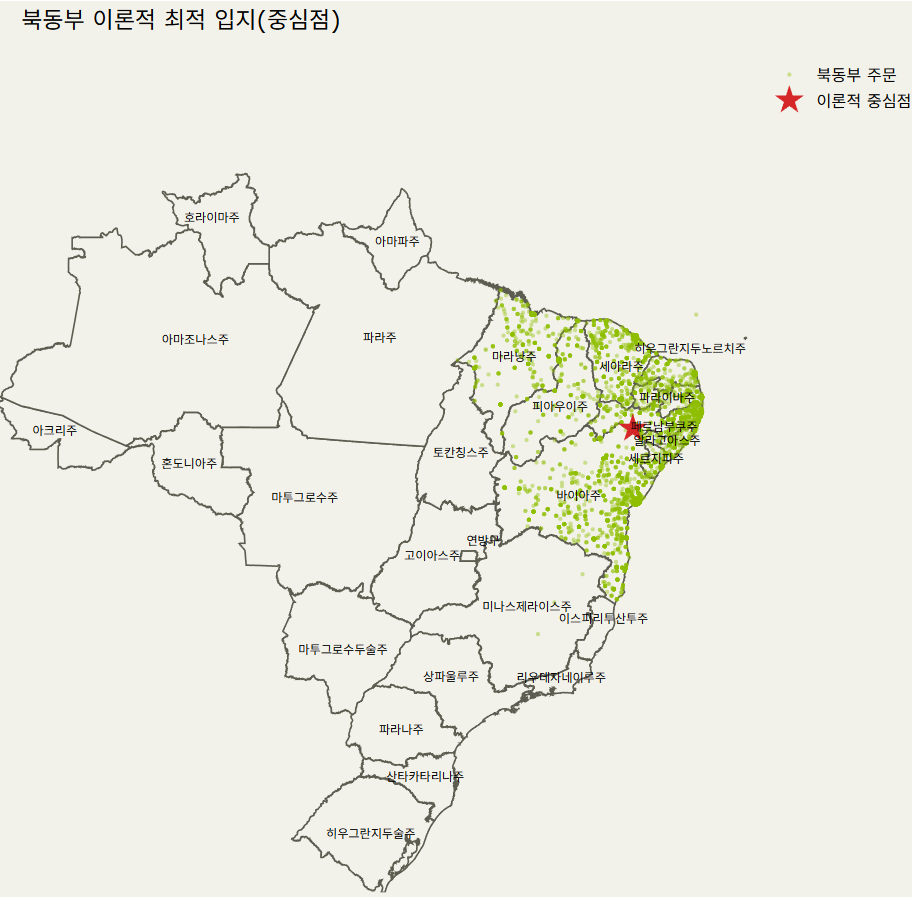

**관찰 - 이론적 중심점 위치**

- 중심점(위도 -8.8527, 경도 -38.6792)은 완전한 오지가 아니라 페르남부쿠주 내륙 쪽, 헤시피 대도시권과 비교적 가까운 위치에 형성됨
- 우려했던 것과 달리 기존 대도시와 아예 동떨어진 지점은 아니라서, 실제 후보 도시 비교에서 헤시피가 유력한 후보로 나올 가능성이 있음

**다음 단계**
- 북동부 내 항구·공항 등 물류 인프라를 갖춘 실제 후보 도시들의 좌표를 확보하고, 각 도시에서 북동부 전체 주문지까지의 평균거리를 계산해 비교한다

**후보 도시 특징 정리**

- 헤시피(페르남부쿠주): 인구 148.9만 - 항구(지역 핵심 터미널)와 공항(북동부 최다 이용) 모두 보유, 상업·호텔·물류 복합개발 진행 중
- 사우바도르(바이아주): 인구 241.8만(북동부 2위) - 항구·공항 모두 보유, 물류기업(Log-In 등)이 신규 거점을 확장하는 중
- 포르탈레자(세아라주): 인구 242.9만(북동부 1위) - 공항 인근에 1,000억원 이상 투자·1.5만 개 일자리 규모의 물류단지가 조성 중이며 북동부 신흥 물류허브로 부상
- 페이라지산타나(바이아주 내륙): 인구 61.6만 - 항구·공항은 없지만 BR-101·BR-116·BR-324 3대 고속도로가 교차하는 남부-북동부 물류 관문으로, 이미 여러 물류센터가 입주해 있음(사우바도르에서 약 110km)

**다음 단계**
- 각 후보 도시에서 북동부 전체 주문지까지의 평균거리를 계산해 거리 효율을 비교한다

In [73]:
# 목적: 북동부 후보 도시별 정보(인구/인프라) + 북동부 전체 주문지까지 평균거리 계산
pd.reset_option('display.float_format')

candidates = pd.DataFrame([
    {'도시': '헤시피', '주': 'PE', 'lat': -8.0476, 'lng': -34.8770, '인구': 1488920,
     '항구': 'O', '공항': 'O(북동부 최다 이용)', '비고': '항만·공항 모두 지역 핵심 터미널, 상업·호텔·물류 복합개발 진행중'},
    {'도시': '사우바도르', '주': 'BA', 'lat': -12.9777, 'lng': -38.5016, '인구': 2417678,
     '항구': 'O', '공항': 'O(2번째로 붐비는 터미널)', '비고': '물류기업(Log-In 등) 신규 거점 확장 중'},
    {'도시': '포르탈레자', '주': 'CE', 'lat': -3.7172, 'lng': -38.5433, '인구': 2428678,
     '항구': 'O(화물중심)', '공항': 'O(1000억원+ 투자 물류단지, 15,000개 일자리)', '비고': '북동부 주요 물류허브로 자리매김 중'},
    {'도시': '페이라지산타나', '주': 'BA', 'lat': -12.2667, 'lng': -38.9667, '인구': 616279,
     '항구': 'X', '공항': 'X', '비고': 'BR-101·BR-116·BR-324 고속도로 교차점, 기존 물류센터 다수 입주(내륙 물류거점)'},
])

def avg_distance_to(city_lat, city_lng, df):
    d = 6371 * np.arccos(np.clip(
        np.sin(np.radians(city_lat)) * np.sin(np.radians(df['lat'])) +
        np.cos(np.radians(city_lat)) * np.cos(np.radians(df['lat'])) * np.cos(np.radians(df['lng']) - np.radians(city_lng)),
        -1, 1
    ))
    return d.mean()

candidates['북동부평균거리_km'] = candidates.apply(lambda r: round(avg_distance_to(r['lat'], r['lng'], ne_customers), 1), axis=1)
candidates.sort_values('북동부평균거리_km')

,도시,주,lat,lng,인구,항구,공항,비고,북동부평균거리_km
3,페이라지산타나,BA,-12.2667,-38.9667,616279,X,X,"BR-101·BR-116·BR-324 고속도로 교차점, 기존 물류센터 다수 입주(내...",549.7
0,헤시피,PE,-8.0476,-34.8770,1488920,O,O(북동부 최다 이용),"항만·공항 모두 지역 핵심 터미널, 상업·호텔·물류 복합개발 진행중",575.3
1,사우바도르,BA,-12.9777,-38.5016,2417678,O,O(2번째로 붐비는 터미널),물류기업(Log-In 등) 신규 거점 확장 중,578.3
2,포르탈레자,CE,-3.7172,-38.5433,2428678,O(화물중심),"O(1000억원+ 투자 물류단지, 15,000개 일자리)",북동부 주요 물류허브로 자리매김 중,695.4


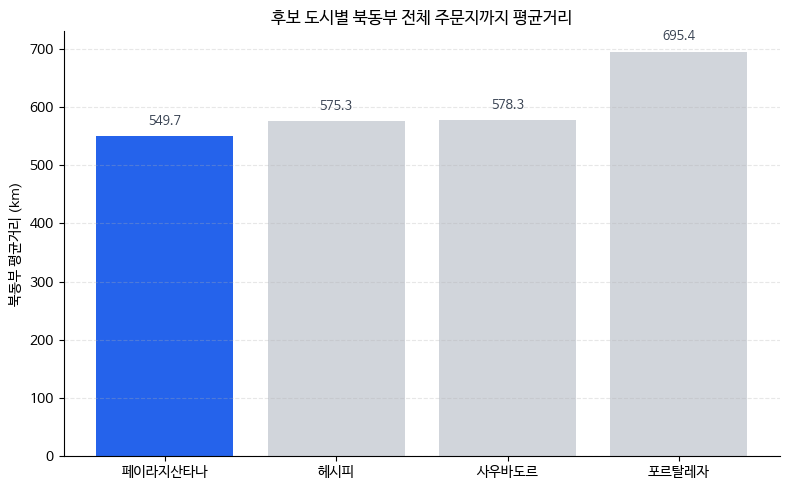

In [78]:
# 목적: 후보 도시별 북동부 평균거리 비교 시각화
import matplotlib.pyplot as plt

candidates_sorted = candidates.sort_values('북동부평균거리_km')
colors = ['#2563EB' if city == '페이라지산타나' else '#D1D5DB' for city in candidates_sorted['도시']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(candidates_sorted['도시'], candidates_sorted['북동부평균거리_km'], color=colors)

for bar, val in zip(bars, candidates_sorted['북동부평균거리_km']):
    ax.annotate(f'{val:.1f}', (bar.get_x() + bar.get_width()/2, val), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=9, color='#374151')

ax.set_ylabel('북동부 평균거리 (km)')
ax.set_title('후보 도시별 북동부 전체 주문지까지 평균거리')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('candidate_distance.png', dpi=150)
plt.show()

**관찰 - 후보 도시별 거리 효율 비교**

- 페이라지산타나가 북동부 전체 주문지까지 평균거리 549.7km로 가장 짧음
- 헤시피(575.3km), 사우바도르(578.3km)가 근소한 차이로 뒤를 이음
- 포르탈레자는 인구·투자 규모는 가장 크지만 거리가 695.4km로 가장 멀어 - 북동부 북단에 치우친 위치라 지역 전체를 커버하기엔 비효율적

**결론**

- 이커머스 소포 배송은 항구(해상)·공항(항공)보다 도로망 의존도가 훨씬 높음 - 이 기준으로 보면 페이라지산타나가 거리 효율 1위이면서, 이미 3대 고속도로 교차점이자 기존 물류센터가 다수 입주한 곳이라 실질적 적합도가 가장 높음
- 헤시피·사우바도르는 항구·공항까지 갖춘 대도시라 인력 확보나 확장성 면에서는 유리하지만, 도로 기반 소포 배송 거점이라는 목적에는 필수 요소는 아님
- 다만 페이라지산타나는 인구 61.6만으로 대도시 대비 적어, 인력 확보 측면에서는 상대적으로 불리할 수 있음 - 한계로 남겨둠

**최종 제안**

- 페이라지산타나(바이아주)를 1차 물류거점(크로스독) 입지로 제안 - 거리 효율 1위 + 기존 도로 기반 물류 인프라 보유
- 헤시피·사우바도르는 인구·인프라 규모가 커 향후 수요 증가 시 2차 거점 후보로 함께 제시

**기대효과 - 물류거점 도입 시 예상 개선 효과**

- 목적: 페이라지산타나 허브 도입이 북동부 배송소요일에 미치는 영향을 정량적으로 추정한다 (통신기기·헬스&뷰티·시계&선물용품 등 재고 사전배치가 가능한 카테고리를 가정)
- 방법: 북동부 현재 평균거리와 허브 도입 시 평균거리(허브-구매자 거리)의 차이에 H5에서 구한 회귀기울기(거리 1km당 배송소요일 영향)를 적용해 예상 배송소요일 감소분을 계산하고, 남동부 현재 수준과 비교한다
- 배송소요일 감소 외에 리뷰점수 개선, 북동부 주문량 증가(현재 남동부 대비 낮은 주문량 격차 완화)는 정량 추정 대신 방향성 수준으로만 언급한다

In [74]:
# 목적: 물류거점(페이라지산타나) 도입 시 예상 배송소요일 감소 계산
se_states = ['SP','RJ','MG','ES']

ne_orders = h5_base[h5_base['지역코드'].isin(ne_states)]
se_orders = h5_base[h5_base['지역코드'].isin(se_states)]

current_avg_distance = ne_orders['distance_km'].mean()
current_avg_delivery = ne_orders['배송소요일'].mean()
se_avg_delivery = se_orders['배송소요일'].mean()

hub_avg_distance = candidates.loc[candidates['도시'] == '페이라지산타나', '북동부평균거리_km'].values[0]
slope = h5_corr['회귀기울기_배송소요일'].values[0]

distance_reduction = current_avg_distance - hub_avg_distance
expected_delivery_reduction = distance_reduction * slope
expected_new_delivery = current_avg_delivery - expected_delivery_reduction

print(f"북동부 현재 평균거리: {current_avg_distance:.1f}km")
print(f"허브 도입 시 평균거리: {hub_avg_distance:.1f}km (감소 {distance_reduction:.1f}km)")
print(f"북동부 현재 평균배송소요일: {current_avg_delivery:.2f}일")
print(f"예상 배송소요일 감소분: {expected_delivery_reduction:.2f}일")
print(f"허브 도입 후 예상 평균배송소요일: {expected_new_delivery:.2f}일")
print(f"참고 - 남동부 현재 평균배송소요일: {se_avg_delivery:.2f}일")

북동부 현재 평균거리: 1781.7km
허브 도입 시 평균거리: 549.7km (감소 1232.0km)
북동부 현재 평균배송소요일: 19.89일
예상 배송소요일 감소분: 7.76일
허브 도입 후 예상 평균배송소요일: 12.13일
참고 - 남동부 현재 평균배송소요일: 10.64일


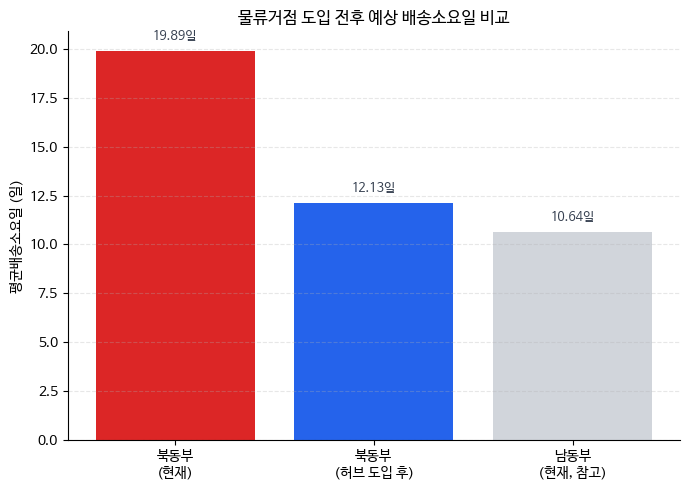

In [79]:
# 목적: 물류거점 도입 전후 배송소요일 비교 시각화
import matplotlib.pyplot as plt

labels = ['북동부\n(현재)', '북동부\n(허브 도입 후)', '남동부\n(현재, 참고)']
values = [current_avg_delivery, expected_new_delivery, se_avg_delivery]
colors = ['#DC2626', '#2563EB', '#D1D5DB']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors)

for bar, val in zip(bars, values):
    ax.annotate(f'{val:.2f}일', (bar.get_x() + bar.get_width()/2, val), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=9, color='#374151')

ax.set_ylabel('평균배송소요일 (일)')
ax.set_title('물류거점 도입 전후 예상 배송소요일 비교')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('expected_effect.png', dpi=150)
plt.show()

**관찰 - 물류거점 도입 기대효과**

- 북동부 평균거리는 현재 1,781.7km에서 허브 도입 시 549.7km로 약 1,232km(69%) 감소
- 이 거리 감소를 H5 회귀모델에 적용하면 평균배송소요일이 19.89일에서 12.13일로 약 7.76일(39%) 단축될 것으로 추정
- 다만 이 값은 여전히 남동부 현재 평균(10.64일)보다 길어 - 격차를 완전히 해소하진 못하지만 상당 부분 좁혀짐

**결론**

- 물류거점 도입으로 북동부 배송소요일을 약 39% 단축할 수 있을 것으로 기대됨(19.89일 → 12.13일)
- 배송소요일 단축은 리뷰점수 개선으로 이어질 가능성이 높음 - H5에서 확인했듯 리뷰점수 하락은 특히 거리/소요일이 극단적으로 긴 구간에 집중돼 있어, 이 구간이 줄어들면 개선 효과가 클 것으로 예상됨
- 현재 남동부(65,704건) 대비 북동부(8,962건)는 주문량 격차도 상당한데, 배송 경험 개선이 이 격차를 좁히는 데 기여할 가능성도 있음
- 다만 리뷰점수 개선폭과 주문량 증가분은 정량적으로 추정하지 않고 방향성 수준으로만 제시함 - 실제 검증에는 파일럿 운영 후 데이터가 필요함

# 최종 결론 및 한계

**전체 요약 (H1-H5)**

- H1 채택: 배송소요일이 짧을수록 리뷰점수가 높음(피어슨 -0.34) - 다만 하락이 선형이 아니라 극단적으로 긴 소요일 구간(상위 10%)에 집중
- H2 채택: 소요일 자체보다 "정시성(지연 여부)"이 리뷰점수를 더 잘 설명함(R² 0.154 vs 0.117) - 같은 소요일이라도 지연이면 리뷰점수가 최대 1.8점 더 낮음
- H3 채택(조건부): 지연 폭이 클수록 리뷰점수가 낮아지지만 31일 이상에서는 평균이 반등 - 실제로는 다수(66%)가 여전히 최악 점수를 주고, 소수(22%)의 CS 보상 추정 케이스가 평균을 끌어올린 이중분포
- H4 채택: 지연이 리뷰에 미치는 영향력(기울기)은 지역별로 최대 25배 차이 - 세르지피주 등이 특히 민감, 아마조나스주는 유일하게 양의 기울기
- H5 채택: 판매자-구매자 거리가 배송소요일에 전 구간 확실한 영향(스피어만 0.541), 리뷰점수는 최상위 10% 거리에서만 약하게 영향 - H4의 지역별 민감도 차이가 상당 부분 이 거리 차이에서 비롯됨

**액션 제안**

- 판매자 위치를 통제할 수 없는 마켓플레이스 구조상, 회사가 통제 가능한 변수인 물류거점을 판매자 희소·지연 심한 북동부에 제안
- 카테고리 구성 차이가 크지 않아 카테고리 무관 크로스독 모델을 기본으로 채택, 거리 효율(549.7km, 최단) + 기존 도로 인프라(BR-101·116·324 교차점)를 근거로 페이라지산타나를 1차 후보로 도출
- 기대효과로 북동부 평균배송소요일 19.89일 → 12.13일(약 39% 단축) 추정

**한계**

- 기대효과 계산은 "허브에 재고를 사전배치(풀필먼트)"하는 가정에서 나온 수치인 반면, 실제 채택한 모델은 카테고리 무관 크로스독임 - 크로스독은 물리적 거리 자체를 줄이지 않고 처리 효율만 높이는 방식이라, 이 39% 단축 효과가 크로스독 모델에도 그대로 적용된다고 보기는 어려움. 두 모델 간 가정 불일치를 인지하고, 풀필먼트로 확장 가능한 일부 카테고리에 한정된 추정치로 해석해야 함
- H3의 31일 이상 반등 구간에서 소수 그룹(22%)이 CS 보상으로 점수를 회복했을 것이라는 해석은 검증되지 않은 추정
- H4의 아마조나스주(유일한 양의 기울기)는 원인을 조사하지 않고 단순 관찰로 남김
- H5의 거리-리뷰점수 상관관계는 약함(피어슨 -0.058) - 거리가 리뷰점수에 미치는 영향은 배송소요일을 매개로 한 간접효과일 가능성이 높음
- 남동부 vs 북동부 권역 비교는 다른 지역 특성(소득수준, 인터넷 보급률 등)이 섞여있을 수 있어 완전한 인과로 단정하기 어려움
- 후보 도시 선정에 쓴 인구 수치는 2022년 IBGE 센서스 기준이며, 실제 운영비용(임대료, 인건비, 세제혜택 등)은 고려하지 않음
- 전체 분석은 2016-2018년 데이터 기반으로, 현재 시점의 인프라·인구 변화는 반영되지 않음